# Load modules

In [2]:
import os
import itk
import cv2
import sys
import json
import glob
import time
import imageio
import numpy as np
import pandas as pd
import nibabel as nib
import pydicom as dcm
from matplotlib import colors
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from lmfit import minimize, Parameters

from urllib.request import urlopen
from datetime import datetime as dtime



# Auxiliar Functions
## Utils

In [3]:
def getenv():
    """
    Requires sys and os modules:
    import sys
    import os
    """
    if sys.platform == 'win32':
        env_home = 'HOMEPATH'
    elif (sys.platform == 'darwin') | (sys.platform == 'linux'):
        env_home = 'HOME'
    HOMEPATH = os.getenv(env_home)
    
    return HOMEPATH

def check_path_exist(path, file=False):
    """
    Flag FILE indicates the path contains a file name (FLAG=TRUE) or the path only points to a folder (FLAG=FALSE (Default))
    """
    if file:
        is_path = os.path.isfile(path)
    else:
        is_path = os.path.isdir(path)

    print(f'{"OK:" if is_path else "ERROR:"} Path to {"file" if file else "folder"} {path} does{"" if is_path else " NOT"} exist')

    return is_path

def list_folder(path, skip_patterns=None, sorted=False):
    # Check the path exists:
    if not(os.path.isdir(path)):
        error_message = f'[ERROR]: Folder path {path} does not exist'
        sys.exit(error_message)
    
    raw_list = os.listdir(path)
    
    # Ensure patterns is a list, defaulting to ['.DS_Store']
    dsStorePattern = '.DS_Store'
    if skip_patterns is None:
        skip_patterns = [dsStorePattern]
    elif isinstance(skip_patterns, str):
        skip_patterns = [dsStorePattern, skip_patterns]  # Convert single string to list
    elif isinstance(skip_patterns, (list, tuple, set)):  
        skip_patterns = list(skip_patterns)  # Ensure it's a list
        if dsStorePattern not in skip_patterns:
            skip_patterns.append(dsStorePattern)  # Add default pattern if not already included
    else:
        raise TypeError("patterns must be a string, list, tuple, or set.")

    # dir_list = [item for item in raw_list if skip_pattern not in item]
    # any(p in item for p in skip_patterns) checks if any pattern in skip_patterns exists in item:
    dir_list = [item for item in raw_list if not any(p in item for p in skip_patterns)]

    if sorted:
        dir_list.sort()

    return dir_list


# Function to parse mixed datetime formats
def parse_mixed_datetime(ts, format='%Y%m%d%H%M%S.%f'):
    """
    # Ensure all values have milliseconds (force `.0000` if missing) before the conversion:
    """

    ts_f = ts.apply(lambda x: f"{x}.0000" if pd.notna(x) and "." not in str(x) else x)

    return pd.to_datetime(ts_f, format=format, errors="coerce")

def filter_list(lst, pattern):
    return [item for item in lst if pattern not in item]

def get_list_element(lst, pattern):
    return [item for item in lst if pattern in item]


## Enrst Angles and SPGR equations

In [4]:
def E1(TR, T1):
    
    return np.exp(-TR/T1)

def E2(TE, T2):
    
    return np.exp(-TE/T2)

def fzss(TR, T1, FA_rad):
    
    return (1.0 - E1(TR, T1))/(1.0 - np.cos(FA_rad)*E1(TR, T1))

def s0sinalfa(M0, FA_rad):

    return M0 * np.sin(FA_rad)

def st(M0, T1, TR, FA_rad, TE=np.nan, T2=np.nan):

    stT1 = s0sinalfa(M0, FA_rad) * fzss(TR, T1, FA_rad)
    
    if (np.isnan(T2)) | (np.isnan(TE)):
        return stT1
    else:
        #eq  with t2* decay
        return stT1 * E2(TE,T2)

def ernstAngle(TR, T1):
    # Flip Angle that maximises the signal for a given TR and T1 (REF: Handbook of MRI Pulse Sequences, page 587, Eq. 14.9)
    
    return np.rad2deg(np.arccos(E1(TR, T1)))

def anglesT1Maps(TR,T1):
    # Flip angles for optimal T1 Mapping with only 2 acq (REF: Deoni SCL 2003, Rapid Combined T1 and T2 mapping using..., MRM 49:515-526)
    
    f = 0.71 # see REF
    angle1 = (E1(TR, T1)*np.square(f) + (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    angle2 = (E1(TR, T1)*np.square(f) - (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    Angles = np.array([angle1,angle2])
    #return Angles
    return np.rad2deg(np.arccos(Angles))


## Helper functions for Linear T1 mapping

In [5]:
# Define a simple atomic function to perform linear fit 
# Add a check before fitting
def safe_polyfit(x, y):
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        return np.nan, np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    if np.any(x == 0.0) or np.any(y == 0.0):
        return np.nan, np.nan    
    try:
        m, n = np.polyfit(x, y, deg=1)
        return m, n
    except Exception:
        return np.nan, np.nan
    
# Function to apply polyfit to a single pixel across the flip angles
def linfit_pixel(X, Y, i, j, k):
    x_vals = X[:, k, j, i]
    y_vals = Y[:, k, j, i]

    # try:
    mslope, nintercept = safe_polyfit(x_vals, y_vals)
    # except Exception:
    #     mslope = np.nan
    #     nintercept = np.nan

    return (i, j, k, mslope, nintercept)


## Optimisation functions for nonlinear T1 map estimation

In [6]:
# Define cost functions to estimate T1 with SPGR and IR
def fit_SPGR_t1(params, flip_angle_rad, values):
    s0 = params['s0'].value
    t1 = params['t1'].value
    tr = params['tr'].value
    te = params['te'].value
    t2star = params['t2star'].value

    s = st(s0, t1, tr, flip_angle_rad, te, t2star)
    
    return (np.fabs(s) - np.fabs(values))

# Define the optimisation method
def do_spgr_fit(ydata, fa_rad, tr, te=np.nan, t2star=np.nan, initial_s0=1.0, initial_t1=1000.0, T1ub = 10000.0):
    params = Parameters()
    params.add('s0', value=initial_s0, vary=True, min=0.0)
    params.add('t1', value=initial_t1, vary=True, min=0.0, max=T1ub)
    params.add('tr', value=tr, vary=False)
    params.add('te', value=te, vary=False)
    params.add('t2star', value=t2star, vary=False)
    
    result = minimize(fit_SPGR_t1, params, args=(fa_rad, ydata))

    return result    

def safe_nonlinfit(ydata, flipangles_rad, m0, t10, TR, TE, T2star, T1ub):

    if np.any(np.isnan(ydata)):
        return np.nan, np.nan
    
    if np.all(ydata == ydata[0]):
        return np.nan, np.nan
        
    try:
        nonlin_fit_output = do_spgr_fit(ydata, flipangles_rad, TR, TE, T2star, 
                                        T1ub=T1ub,
                                        initial_s0=m0, initial_t1=t10)
        return nonlin_fit_output.params['t1'].value, nonlin_fit_output.params['s0'].value    

    except Exception:
        return np.nan, np.nan
 
# Function to apply nonlinear fit to a single pixel across the flip angles
def nonlinfit_pixel(Y, FlipAngleRad, T10, TR, T1ub, i, j, k, TE=np.nan, T2star=np.nan):
    ydata = Y[:, k, j, i]

    t1hat, m0hat = safe_nonlinfit(ydata, FlipAngleRad, m0=np.max(ydata), t10=T10, TR=TR, TE=TE, T2star=T2star, T1ub=T1ub)

    return (i, j, k, t1hat, m0hat)


## T1 mapping algorithms

In [7]:
def t1fit_vfa(VFA_listOfImages, VFA_listOfFlipAngles, VFA_parameters, T10=1000.0, FitAlgo='rational_linear', flip_angle_units = 'deg', T1ub=5000.0, T1lb=100.0):
    # Algorithms can be:
    # rational_linear --> Rational Approximation (Helms et al., 2008)
    # std_linear    --> Linear approximation (Gutpa, 1977)
    # non_linear    --> Non-linear ("exact" fitting)

    # List of images must match the length of the flip angles:
    nImages = len(VFA_listOfImages)
    nFlipAngles = len(VFA_listOfFlipAngles)

    if nImages != nFlipAngles:
        print(f'[ERROR]: Length of images {nImages} does not match the list of flip angles {nFlipAngles}')
        sys.exit()

    if nImages < 2:
        print(f'[ERROR]: Not enough images {len(nImages)} to perform the calculations')
        sys.exit()

    # At least we need the TR for the fitting
    if 'TR' not in VFA_parameters.keys():
        print('[ERROR]: Parameter TR is not available, cannot perform the fitting')
        sys.exit()
    
    # If required, convert the flip angles from degree to radians (default behaviour)
    if flip_angle_units == 'deg':
        flip_angles_radians = [np.deg2rad(x) for x in VFA_listOfFlipAngles]
    else:
        flip_angles_radians = VFA_listOfFlipAngles.copy()

    # Call the fitting function 
    if FitAlgo == 'rational_linear':
        if nImages > 2:
            print('[WARNING]: Algorithm {FitAlgo} requires only 2 Flip angles, but {nImages} were provided')
            print(f'Will use only the first 2 flip angles ({flip_angles_radians[:2]})')
            nImages = 2
        T1, M0 = rational_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'std_linear':
        T1 = 0
        M0 = 0
        T1, M0 = standard_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'non_linear' :
        T1 = 0
        M0 = 0
        T1, M0 = nonlinear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], T10, VFA_parameters['TR'], T1ub=T1ub)
    else:
        print(f'[ERROR]: Method {FitAlgo} is not yet implemented')
        T1 = []
        M0 = []
        sys.exit()
    
    return T1, M0

def rational_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):
    
    if 0.0 in VFA_flipangles_rad:
        print('[ERROR]: One of the angles is 0, cannot perform the calculations')
        sys.exit()

    Tnum = (VFA_images[0] / VFA_flipangles_rad[0]) - (VFA_images[1] / VFA_flipangles_rad[1]) 
    Tden = (VFA_images[1] * VFA_flipangles_rad[1]) - (VFA_images[0] * VFA_flipangles_rad[0])
    Tden += 1e-6

    T1map = 2.0 * TR * Tnum / Tden

    # T1map[np.isnan(T1map)] = 1.0
    T1map[T1map > T1ub] = 0.0
    T1map[T1map < T1lb] = 0.0

    Anum = (VFA_flipangles_rad[1]/VFA_flipangles_rad[0] - VFA_flipangles_rad[0]/VFA_flipangles_rad[1])
    Aapp = VFA_images[0] * VFA_images[1] * Anum / Tden
    # Aapp[np.isnan(Aapp)] = 0.0
    Aapp[Aapp < 0.0] = 0.0

    return T1map, Aapp

def standard_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):


    # Create the xi and yi elements for the X and Y lists (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    X = np.array([fa_image/np.tan(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    Y = np.array([fa_image/np.sin(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    if len(X.shape) == 1:
        X = X[:, np.newaxis, np.newaxis, np.newaxis]
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(X.shape) == 2:
        X = X[:, :, np.newaxis, np.newaxis]
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(X.shape) == 3:
        X = X[:, :, :, np.newaxis]
        Y = Y[:, :, :, np.newaxis]
    
    nFA, nS, nH, nW = X.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(linfit_pixel)(X, Y, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    m = np.zeros((nS, nH, nW))
    n = np.zeros((nS, nH, nW))
    for i, j, k, mijk, nijk in results:
        m[k, j, i] = mijk
        n[k, j, i] = nijk
    
    T1hat = -TR / np.log(m)
    T1hat[np.isnan(T1hat)] = 0.0
    T1hat[T1hat > T1ub] = 0.0
    T1hat[T1hat < T1lb] = 0.0
    
    M0hat = n/(1-m)

    return T1hat, M0hat

def nonlinear_t1_fit(VFA_images, VFA_flipangles_rad, T10, TR, T1ub):
    
    # def nonlinfit_pixel(Y, FlipAngle, i, j, k, TR, TE=None, T2start=None):
    
    # Create the yi elements for the Y list (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    Y = np.array(VFA_images)
    if len(Y.shape) == 1:
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(Y.shape) == 2:
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(Y.shape) == 3:
        Y = Y[:, :, :, np.newaxis]

    nFA, nS, nH, nW = Y.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(nonlinfit_pixel)(Y, VFA_flipangles_rad, T10, TR, T1ub, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    T1hat = np.zeros((nS, nH, nW))
    M0hat = np.zeros((nS, nH, nW))

    for i, j, k, t1est, m0est in results:
        T1hat[k, j, i] = t1est
        M0hat[k, j, i] = m0est

    T1hat[np.isnan(T1hat)] = 0.0
    # T1hat[T1hat > T1ub] = 0.0
    # T1hat[T1hat < 0.0] = 0.0

    return T1hat, M0hat


## Pre-processing T1 map

In [8]:
def nt4k_bias_correction(input_itk_volume, simple=False):

    # Cast to float if needed
    input_volume = itk.cast_image_filter(input_itk_volume, ttype=[type(input_itk_volume), itk.Image[itk.F, 3]])

    # Create a mask (you can use the whole image or a thresholded region)
    mask_image = itk.Image[itk.UC, 3].New()
    mask_image.SetRegions(input_volume.GetLargestPossibleRegion())
    mask_image.CopyInformation(input_volume)
    mask_image.Allocate()
    mask_image.FillBuffer(1)  # Whole image as mask

    # Initialize the N4 bias field correction filter
    n4_filter = itk.N4BiasFieldCorrectionImageFilter.New(Input=input_volume, MaskImage=mask_image)

    if not simple:
        # # Set the shrink factor (4 is usually ok)
        n4_filter.SetNumberOfFittingLevels(4)

        # Optionally, set parameters (like number of iterations per level)
        n4_filter.SetMaximumNumberOfIterations([100, 70, 50, 30]) # for an input volume of size [120, 528, 528]

    # Update the filter to perform the correction
    n4_filter.Update()

    # Get the output image
    output_itk_volume = n4_filter.GetOutput()

    return output_itk_volume


In [9]:
def numpy_to_itk(numpy_array, reference_itk_volume):

    # Convert back to ITK image (note: GetArrayFromImage returns z,y,x => shape must match!)
    img_itk = itk.GetImageFromArray(numpy_array)

    # Copy spatial metadata from input_volume_1
    img_itk.SetOrigin(reference_itk_volume.GetOrigin())
    img_itk.SetSpacing(reference_itk_volume.GetSpacing())
    img_itk.SetDirection(reference_itk_volume.GetDirection())

    return img_itk


## Dicom Information

In [10]:
def flatten_tags_dictionary(tag_dictionary):
    # TAG_DICTIONARY is a 2-level dictionary
    # The output is a 1-d list containing the 2nd level tags 

    upper_level_tags = tag_dictionary.keys()
    flattened_tags = []
    for ul_tag in upper_level_tags:
        subsetDataLabels = list(tag_dictionary[ul_tag].keys())
        flattened_tags += subsetDataLabels

    # Add the absolute filepath to the dataframe:
    flattened_tags.append('AbsFilePath')

    return flattened_tags


In [11]:
def load_dicom_file(path_to_dicom_file, tags_to_read, read_pixel_tag=False):

    # Reads an individual DICOM file and returns the metadata and image (if required)

    dcm_object = dcm.dcmread(path_to_dicom_file, stop_before_pixels = not(read_pixel_tag))

    dcm_metadata_fields = flatten_tags_dictionary(tags_to_read)
    dcm_metadata = [None]*len(dcm_metadata_fields)

    for tagSubSetName, tagSubSetFields in tags_to_read.items():
        # print(f'TagSubSetName: {tagSubSetName}')
        for tagName, tagValue in tagSubSetFields.items():
            try:
                dcm_metadata[dcm_metadata_fields.index(tagName)] = dcm_object[tagValue['hex']].value
            except Exception:
                # print(f'Attribute {tagName} does not exist, skipping it...')
                pass
    
    # Add the filepath:
    dcm_metadata[dcm_metadata_fields.index('AbsFilePath')] = path_to_dicom_file
    dicom_object = {'metadata': dcm_metadata}

    if read_pixel_tag:
        dicom_object['image'] = dcm_object.pixel_array

    return dicom_object 


In [12]:
def get_image_dataset(dataset_df, patientID, visit_to_load, sequenceNamePattern, use_philips_rescale=True):

    df_metadata_patient = dataset_df[dataset_df['PatientID'] == patientID]
 
    visits_in_patient = df_metadata_patient['StudyDate'].unique().tolist()
    visits_in_patient.sort()
    
    scanDate = visits_in_patient[ visit_to_load - 1 ]

    df_metadata_patient_visit = df_metadata_patient[df_metadata_patient['StudyDate'] == scanDate]

    df_metadata_patient_visit_sequence = df_metadata_patient_visit[df_metadata_patient_visit['SeriesDescription'].str.startswith(sequenceNamePattern)].copy()
    # Sort by slice location, then by TemporalPositionIdentifier and then load the images 
    # (the copy() above is to avoid the SettingWithCopyWarning message when inplace sorting)
    df_metadata_patient_visit_sequence.sort_values(by=['z', 'TemporalPositionIdentifier'], inplace=True)

    sequenceName = df_metadata_patient_visit_sequence['SeriesDescription'].unique()[0]

    scanTime = df_metadata_patient_visit_sequence.SeriesTime.unique()
    if len(scanTime) > 1:
        print('WARNING: Scan Time registered for the sequence is no unique!, if this is ok, ignore this message')
    scanDateTime = dtime.strptime("-".join([scanDate, scanTime[0]]), "%Y%m%d-%H%M%S.%f")


    print(f'Selected Patient {patientID}, visit {visit_to_load}, Sequence {sequenceName} (from {dtime.strftime(scanDateTime, "%d/%m/%Y @%H:%M:%S")})')


    # Characterise the size of the dataset
    # Rows and Columns must be the same for the whole series:
    nrows_list = df_metadata_patient_visit_sequence['Rows'].unique()
    ncols_list = df_metadata_patient_visit_sequence['Columns'].unique()
    if (len(nrows_list) > 1) | (len(ncols_list)>1):
        print(f'WARNING: Either the number of ROWS ({nrows_list}) or COLUMNS ({ncols_list}) is not consistent for the Series')
    [w, h] = [ncols_list[0], nrows_list[0]]

    slice_locations = df_metadata_patient_visit_sequence['z'].unique()
    ns = len(slice_locations)

    number_of_temporal_positions = df_metadata_patient_visit_sequence['NumberOfTemporalPositions'].unique()
    # numberOfTempPositions must be only 1 element length, because it must be the same for a single Series (afaik)
    temporal_positions = df_metadata_patient_visit_sequence['TemporalPositionIdentifier'].unique()

    if len(number_of_temporal_positions) > 1:
        print(f'WARNING: Check you are processing only one series, the length of temporal_positions is {len(number_of_temporal_positions)}')
        sys.exit()
    nt = number_of_temporal_positions[0]

    print(f'Dataset {patientID}-{scanDate}-{sequenceName} contains {ns} slices and {nt} temporal positions of size {w}x{h} (WxH)')

    # Image resolution and slice spacing
    # df_metadata_patient_visit_sequence['PixelSpacing']
    [resRows, resCols]= df_metadata_patient_visit_sequence['PixelSpacing'].apply(pd.Series).T.values.tolist()
    deltaRow, deltaCol = [np.unique(resRows), np.unique(resCols)]

    # resolution along the slice direction:
    delta_z = df_metadata_patient_visit_sequence['SliceThickness'].unique()

    if (len(deltaRow) > 1) | (len(deltaCol) > 1) | (len(delta_z) > 1):
        print('WARNING: Check you are processing only one series')
        print(f'\t the length of the resolutions parameters is not 1 for Rows ({len(deltaRow)}), Columns ({len(deltaCol)}) and/or slice ({len(delta_z)})')
        sys.exit()

    resx_W, resy_H, resz_Z = [deltaRow[0], deltaCol[0], delta_z[0]]
    print(f'Image resolution is {resx_W:.3f}x{resy_H:.3f}x{resz_Z:.2f} [mm/pixel] (WxHxZ)')


    # Load the data, remember the dataframe is already sorted by slice->time:
    # Remember the array order in numpy is W(rows), H(cols), Z(slice)
    image4D = np.full((w, h, ns, nt), np.nan)
    timeaxis_spatial_temporal = np.full((ns, nt), np.nan)
    zlocation_spatial_temporal = np.full((ns, nt), np.nan)

    for dicom_file_row, dicom_datafile in df_metadata_patient_visit_sequence.iterrows():
        dcm_object = dcm.dcmread(dicom_datafile['AbsFilePath'])
        slice_position = slice_locations.tolist().index(dicom_datafile["z"])
        time_position = temporal_positions.tolist().index(dicom_datafile["TemporalPositionIdentifier"])

        dcm_image_32bit = dcm_object.pixel_array.astype(np.float32)
        # if rescale:
        # According to this thread https://stackoverflow.com/questions/67889762/what-is-the-difference-between-rescale-slope-intercept-and-scale-slope-inter
        # The forumalea relevant are:
        # D = R * RS + RI; R= raw pixel value, RS Rescale Slope (0028,1053), RI Rescale Intercept (0028,1052)
        # P = D / (RS * SS); D= Displayed Value (in the scanner screen), RS Rescale Slope (0028,1053), SS Scale Slope (2005,100E) "PhilipsScaleSlope"
        dcm_image_32bit *= dicom_datafile['RescaleSlope']
        dcm_image_32bit += dicom_datafile['RescaleIntercept']
        if use_philips_rescale:
            dcm_image_32bit /= (dicom_datafile['RescaleSlope'] * dicom_datafile['PhilipsScaleSlope'])

        image4D[:,:,slice_position, time_position] = dcm_image_32bit
        # Get the timing (secs) and location (mm) of each slice, in secs. It allows to easily get the time axis when plotting the data
        timeaxis_spatial_temporal[slice_position, time_position] = dicom_datafile['perSliceAcquisitionTimeInSecs']
        zlocation_spatial_temporal[slice_position, time_position] = dicom_datafile['z']
    
    scanDetails = {'scanDateTime': scanDateTime,
                   'sequenceName': sequenceName,
                   'TR': df_metadata_patient_visit_sequence['RepetitionTime'].unique().tolist(),
                   'TE': df_metadata_patient_visit_sequence['EchoTime'].unique().tolist(),
                   'FA': df_metadata_patient_visit_sequence['FlipAngle'].unique().tolist(),
                   'ETL': df_metadata_patient_visit_sequence['EchoTrainLength'].unique().tolist()
                   }

    return image4D, zlocation_spatial_temporal, timeaxis_spatial_temporal, scanDetails


In [13]:
dicom_dictionary = {
'ID': { # Patient and Study ID
            'StudyID': {'hex': 0x00200010,
                         #  'type': str
                         },
            'PatientName': {'hex': 0x00100010,
                         #    'type': str
                            },
            'PatientID': {'hex': 0x00100020,
                         #  'type': str
                         }
     },
'SeriesID': { # Acquisitions and Series ID
            'SeriesDescription': {'hex': 0x0008103e,
                         #  'type': str
                         },
            'SeriesNumber': {'hex': 0x00200011,
                         #  'type': pd.Int64Dtype()
                         },
            'AcquisitionNumber': {'hex': 0x00200012,
                              #     'type': pd.Int64Dtype()
                                  },
            'InstanceNumber':{'hex': 0x00200013,
                              # 'type': pd.Int64Dtype()
                             }
            # 'ImagesInAcquisition': {'hex': 0x00201002,
            #                   #     'type': pd.Int64Dtype()
            #                       }
          },
'DatesTimes': { #  Dates & Times
            'StudyDate': {'hex': 0x00080020,
                         #  'type': str
                         },
            'StudyTime': {'hex': 0x00080030,
                         #  'type': str
                         },
            'SeriesDate': {'hex': 0x00080021,
                         #  'type': str
                         },
            'SeriesTime': {'hex': 0x00080031,
                         #  'type': str
                         },
            'AcquisitionDate': {'hex': 0x00080022,
                         #  'type': str
                         },
            'AcquisitionTime': {'hex': 0x00080032,
                         #  'type': str
                         },
          #   'AcquisitionDateTime': {'hex': 0x0008002A,
          #                          'type': str
          #                },
            'AcquisitionDuration': {'hex': 0x00189073, # Duration of the single continuous gathering of data over a period of time that resulted in this instance, in seconds.
                                   #  'type': pd.Float64Dtype()
                                    },
            'ContentDate': {'hex': 0x00080023,
                         #  'type': str
                         },
            'ContentTime': {'hex': 0x00080033,
                         #    'type': str
                            },
            'InstanceCreationDate': {'hex': 0x00080012,
                         #  'type': str
                         },
            'InstanceCreationTime': {'hex': 0x00080013,
                         #  'type': str
                         },
            'PerformedProcedureStepEndDate': {'hex': 0x00400250,
                         #  'type': str
                         },
            'PerformedProcedureStepEndTime': {'hex': 0x00400251,
                         #  'type': str
                         }
          },
'AcqPars': { # Acquisition Parameters
            'ImageType': {'hex': 0x00080008,
                        #   'type': 
                        },
            'ScanningSequence': {'hex': 0x00180020,
                                 },
            'SequenceVariant': {'hex': 0x00180021,
                                 },
            'ScanOptions': {'hex': 0x00180022, # Parameters of scanning sequence.
                         #    'type': str
                            },
            'MRAcquisitionType': {'hex': 0x00180023,
                              #     'type': str
                                  },
            'SequenceName': {'hex': 0x00180024, 
                         #    'type': str
                            },
            'RepetitionTime': {'hex': 0x00180080,
                              #  'type': pd.Float64Dtype()
                               },
            'EchoTime': {'hex': 0x00180081,
                         # 'type': pd.Float64Dtype()
                         },
            'FlipAngle': {'hex': 0x00181314,
                         #  'type': pd.Float64Dtype()
                          },
            'InversionTime': {'hex': 0x00180082,
                              # 'type': pd.Float64Dtype()
                         },
            'NumberOfAverages': {'hex': 0x00180083,
                              # 'type': pd.Int64Dtype()
                         },
            'NumberOfPhaseEncodingSteps': {'hex': 0x00180089,
                                        #    'type': pd.Int64Dtype()
                                           },
            'EchoTrainLength': {'hex': 0x00180091,
                              #   'type': pd.Int64Dtype()
                                },
            'PercentSampling': {'hex': 0x00180093,
                              #   'type': pd.Float64Dtype()
                                },
            'PercentPhaseFieldOfView': {'hex': 0x00180094,
                                        # 'type': pd.Float64Dtype()
                                        },
            'PixelBandwidth': {'hex': 0x00180095,
                              #  'type': pd.Float64Dtype()
                               },
            'TriggerTime': {'hex': 0x00181060, # Time, in msec, between peak of the R wave and the peak of the echo produced
                         #    'type': pd.Float64Dtype()
                            },
            'InPlanePhaseEncodingDirection': {'hex': 0x00181312,
               #   'type': str
                 },
            'TemporalPositionIdentifier': {'hex': 0x00200100,
               #   'type': str
                 },
            'NumberOfTemporalPositions': {'hex': 0x00200105,
                                        #   'type': str
                                          },
            # 'TemporalResolution': {'hex': 0x00200110,
            #                             #   'type': str
            #                               },
            'SliceLocation':{'hex': 0x00201041,
                         #     'type': pd.Float64Dtype()
                            },
            'ImagePositionPatient':{'hex': 0x00200032,
                                   #  'type': object
                                    },
            'SliceThickness': {'hex': 0x00180050,
                              #  'type': pd.Float64Dtype()
                               },
            'SpacingBetweenSlices': {'hex': 0x00180088,
                                   #   'type': pd.Float64Dtype()
                              },
            'ImageOrientationPatient': {'hex': 0x00200037,
                                        # 'type': object
                              },
          },
'ImagePars': { # Reconstruction/Image Parameters
            'AcquisitionMatrix': {'hex': 0x00181310,
                              #     'type': object
                                  },
            'PixelSpacing': {'hex': 0x00280030,
                         #     'type': object
                             },
            'Rows': {'hex': 0x00280010,
                    #  'type': pd.Int64Dtype()
                     },
            'Columns': {'hex': 0x00280011,
                    #     'type': pd.Int64Dtype()
                        },
            # 'PixelAspectRatio': {'hex': 0x00280034,
            #                   #    'type': object
            #                      },
            'ReconstructionDiameter': {'hex': 0x00181100,
                                   #     'type': pd.Float64Dtype()
                                       },
            'RescaleType': {'hex': 0x00281054,
                         #    'type': str
                            },
            'RescaleIntercept': {'hex': 0x00281052, # RI
                         #    'type': pd.Float64Dtype()
                            },
            'RescaleSlope': {'hex': 0x00281053, # RS
                         #    'type': pd.Float64Dtype()
                            },
            # 'PhilipsRWVSlope': {'hex': 0x00409225,  # Philips Private Attribute
            #                   #   'type': pd.Float64Dtype()
            #                    },
            # 'PhilipsRWVIntercept': {'hex': 0x00409224,  # WI, Philips Private Attribute
            #                        #  'type': pd.Float64Dtype()
            #                         },
            'PhilipsScaleSlope': {'hex': 0x2005100E, # SS, Philips Private Attribute
                              #     'type': pd.Float64Dtype()
                                  }
            # 'PhaseNumber': {'hex': 0x20011008, # Philips Private Attribute
            #              #    'type': pd.Int64Dtype()
            #                 }
          },
'ContrastAgent': { # Contrast Agent
            'ContrastBolusAgent': {'hex': 0x00180010,
                         #  'type': str
                         },
            'ContrastBolusRoute': {'hex': 0x00181040,
                         #  'type': str
                         },
            'ContrastBolusVolume': {'hex': 0x00181041,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStartTime': {'hex': 0x00181042,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStopTime': {'hex': 0x00181043,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusTotalDose': {'hex': 0x00181044,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastFlowRate': {'hex': 0x00181046,
                         #  'type': pd.Float64Dtype()
                         },
          }
   }


## Figures and display parameters

In [14]:
[fig_width, fig_height] = [8.0, 6.0]
eps_zerodiv = 1e-2


# Paths and environment variables

In [15]:
HOMEPATH = getenv()
DATAPATH = os.path.join(HOMEPATH, 'Data', 'FTV_DCEMRI_Phase02')

DCMPATH = os.path.join(DATAPATH, 'DICOM')
QCPATH = os.path.join(DATAPATH, 'preliminary_review')
REGPATH = os.path.join(DATAPATH, 'registration')
HTRDCEPATH = os.path.join(DATAPATH, 'htrDCEMRI')

sub_folder_list = [DCMPATH, REGPATH, HTRDCEPATH]
# Check the sub-folder exist, if not creates it:
for sub_folder in sub_folder_list:
    os.makedirs(sub_folder, exist_ok=True)

FEXT = 'dcm'


# Registration Parameters
Define a parameters object using the parameters files available in the [Model Zoo](https://lkeb.ml/modelzoo/). For breast MRI, can use some of the cited in the literature:
* Par0032: [Description](https://lkeb.ml/modelzoo/par0032/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0032) 
* Par0052: [Description](https://lkeb.ml/modelzoo/par0052/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0052) 
* Par0058: [Description](https://lkeb.ml/modelzoo/par0058/) **(not yey used)** - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0058) 

In [16]:
# Create parameters object for a given set of parameters:
parameter_object = itk.ParameterObject.New()

# Where to save the parameters files
reg_pars_save_path = os.path.join(REGPATH, 'pars')
os.makedirs(reg_pars_save_path, exist_ok=True)

url_trunk = 'https://raw.githubusercontent.com/SuperElastix/ElastixModelZoo/refs/heads/master/models/'
parametersID = 'Par0032'
parametersFile = {'Par0032': ['Par0032_bsplines.txt', 'Par0032_rigid.txt'],
                  'Par0052': ['Elastix_Params_Affine.txt', 'Elastix_Params_BSpline.txt'],
                  'Par0058': ['Par0058trans.txt']
}

for parameters_filename in parametersFile[parametersID]:
    url_to_parameter_file = os.path.join(url_trunk, parametersID, parameters_filename)
    local_path_file = os.path.join(reg_pars_save_path, parameters_filename)

    registration_parameter_file_obj = urlopen(url_to_parameter_file)
    with open(local_path_file, "wb") as f:
        f.write(registration_parameter_file_obj.read())

    if os.path.isfile(local_path_file):
        parameter_object.AddParameterFile(local_path_file)

print(parameter_object)


ParameterObject (0x319f576d0)
  RTTI typeinfo:   elastix::ParameterObject
  Reference Count: 1
  Modified Time: 64
  Debug: Off
  Object Name: 
  Observers: 
    none
ParameterMap 0: 
  (BSplineInterpolationOrder 1)
  (CompressResultImage "true")
  (DefaultPixelValue 0)
  (ErodeMask "false")
  (FinalBSplineInterpolationOrder 1)
  (FinalGridSpacingInPhysicalUnits 40)
  (FixedImageDimension 3)
  (FixedImagePyramid "FixedRecursiveImagePyramid")
  (FixedInternalImagePixelType "short")
  (HowToCombineTransforms "Compose")
  (ImagePyramidSchedule 4 4 4 2 2 2 1 1 1)
  (ImageSampler "Random")
  (Interpolator "BSplineInterpolator")
  (MaximumNumberOfIterations 500)
  (Metric "AdvancedMattesMutualInformation")
  (MovingImageDimension 3)
  (MovingImagePyramid "MovingRecursiveImagePyramid")
  (MovingInternalImagePixelType "short")
  (NewSamplesEveryIteration "true")
  (NumberOfHistogramBins 32)
  (NumberOfResolutions 3)
  (NumberOfSpatialSamples 5000)
  (Optimizer "AdaptiveStochasticGradientDescen

# DCEMRI - QC and Preliminary Qualitative Analysis
Review the general enhancement pattern for each dataset. 

First, identify the injection point from the data itself. An initial attempt will look at the average signal intensity over the whole FOV and slices, so a single value for each timepoint is plotted. Based on the plot, design a method, either a threshold or something more elaborated to automatically identify when the injection happened. **The aim of this is to define a BASELINE automatically for each dataset, without prescribing the number of acquisitions**

For definitions of non-PK parameters, check [Kataoka et al., "Ultrafast Dynamic Contrast-enhanced MRI of the Breast: How Is It Used?" Magn Reson Med Sci. 21(1): 83-94; 2022](https://www.jstage.jst.go.jp/article/mrms/21/1/21_rev.2021-0157/_article)

In [38]:
patient_list = list_folder(DCMPATH, sorted=True)
print(patient_list)


['001', '002', '004', '005', '006', '008', '009']


# Select one dataset and extract Quantitative parameters

In [ ]:
patientID = '004'
visitNro = 1 # 1 or 2

study_dates = list_folder(os.path.join(DCMPATH, patientID), sorted=True)
visits_dict = dict(zip(range(1,len(study_dates)+1), study_dates))
visitID = visits_dict[visitNro]

sequences_in_visit = list_folder(os.path.join(DCMPATH, patientID, visitID))

# From the first dicom file available, get the patient ID and study date:
dicom_required_fields = flatten_tags_dictionary(tag_dictionary=dicom_dictionary)
sample_dicom_file = glob.glob(os.path.join(DCMPATH, patientID, visitID, sequences_in_visit[0], '*.dcm'))[0]
dicom_metadata = load_dicom_file(sample_dicom_file, dicom_dictionary)

patient_metadata = dict(zip(dicom_required_fields, dicom_metadata['metadata']))
print('Patient Metadata:')
print(f'\tStudy ID: {patient_metadata["StudyID"]}')
print(f'\tPatient ID: {patient_metadata["PatientID"]}')
print(f'\tStudyDate: {dtime.strftime(dtime.strptime(patient_metadata["StudyDate"], "%Y%m%d"), "%d/%m/%Y")}')


Patient Metadata:
	Study ID: ANON44148
	Patient ID: ANON44148
	StudyDate: 05/04/2023


### Load data

Load the dicom metadata. It will be required to define the time axis

I then have two options: convert to an ITK object or load the dynamic series directly from ITK. I'd prefer the first option, to be more efficient

In [60]:
# Get series within the study date:
htrdce_sequence_pattern = '4D'
htrdce_sequenceID = get_list_element(sequences_in_visit, htrdce_sequence_pattern)[0]
htrdce_path = os.path.join(DCMPATH, patientID, visitID, htrdce_sequenceID)

# Get the list of DCM (or whatever is defined by FEXT) files:
dcmlist = glob.glob(os.path.join(htrdce_path,f'*.{FEXT}'))
print(f'There are {len(dcmlist)} files in {"-".join([patient_metadata["PatientID"], str(visitNro), htrdce_sequenceID])}')
print('Loading dicom files, please wait...')
dicomMetadataList = []
for dcmfile in dcmlist:
    dcm_metadata_row = load_dicom_file(dcmfile, tags_to_read=dicom_dictionary, read_pixel_tag=False)
    dicomMetadataList.append(dcm_metadata_row['metadata'])


There are 3360 files in ANON44148-1-JanBar_ANON44148_MR_2023-04-05_135120_RICE.Functional.Pre.with.Contrast_4D.THRIVE.Ultrafast_n3360__00000
Loading dicom files, please wait...


In [ ]:
df_metadata = pd.DataFrame(columns=flatten_tags_dictionary(tag_dictionary=dicom_dictionary), data=dicomMetadataList)
# Ensures PatientName is a string:
df_metadata['PatientName'] = df_metadata['PatientName'].astype(str)

# Create datetime objects for the paired date and time attributes
date_time_attr = ['InstanceCreation', 'Study', 'Series', 'Acquisition', 'Content']

for datetime_tagName in date_time_attr:
    date_attr = datetime_tagName+'Date'
    time_attr = datetime_tagName+'Time'
    df_metadata[datetime_tagName+'DateTime'] = parse_mixed_datetime(df_metadata[date_attr] + df_metadata[time_attr])

# Additionally, merges the Study Date with Contrast Start/End to ensure they fit in the acquisition window:
df_metadata['ContrastBolusStartDateTime'] = parse_mixed_datetime(df_metadata['StudyDate'] + df_metadata['ContrastBolusStartTime'])
df_metadata['ContrastBolusEndDateTime'] = parse_mixed_datetime(df_metadata['StudyDate'] + df_metadata['ContrastBolusStopTime'])

# Setup a per-slice timing:
# For each Series do the following:
#   - Sort, in ascending order, the TemporalPositionIdentifier
#   - Sort, in ascending order, the slice location (from - to +)
#   - Based on the dataframe index, loop over the Temporal position and populate the new field AcquisitionDateTimeSlice:
# 
df_metadata['perSliceAcquisitionTime'] = [None]*len(df_metadata)
df_metadata['perSliceAcquisitionTimeInSecs'] = [None]*len(df_metadata)
df_metadata['ContrastBolusStartTimeInSecs'] = [None]*len(df_metadata)

# Patient List:
patientList = df_metadata['PatientName'].unique().tolist()
for patient in patientList:
    # Studies List for each patient:
    patient_in_df = df_metadata[df_metadata['PatientName'].isin([patient])]
    studies_in_patient = patient_in_df['StudyDate'].unique().tolist()
    for study_patient in studies_in_patient:
        study_in_patient = patient_in_df[patient_in_df['StudyDate'].isin([study_patient])]
        sequences_in_study = study_in_patient['SeriesDescription'].unique().tolist()
        # min acquisition time between Dyn eTHRIVE and 4D_THRIVE:
        df_aux = study_in_patient[(study_in_patient['SeriesDescription'].str.startswith('4D_THRIVE')) | (study_in_patient['SeriesDescription'].str.startswith('Dyn'))]
        min_time = df_aux['AcquisitionDateTime'].min(skipna=True)
        for sequence_study_patient in sequences_in_study:
            # We're now at the level of series.
            # For the timming, we're only interested in 4D_THRIVE_Ultrafast & Dyn eTHRIVE:
            if sequence_study_patient.startswith('4D_THRIVE') | sequence_study_patient.startswith('Dyn'):
                serie_in_study = study_in_patient[study_in_patient['SeriesDescription'].isin([sequence_study_patient])]
                # Additional Filter to remove the corrupted single file:
                serie_in_study = serie_in_study[serie_in_study['AcquisitionNumber'].notna()]
                # Now, we should be ready to assign the timings:
                # Sort by temporal position:
                serie_in_study.sort_values(by=['TemporalPositionIdentifier', 'SliceLocation'], ascending=(True, False), inplace=True)
                nslices = len(serie_in_study['SliceLocation'].unique().tolist())
                slice_order = range(0, nslices)
                # Here loop over TimePos and slice location using the formula:
                # AcquisitionTime  + TR * TempPos * Range(Slice)
                TR = serie_in_study['RepetitionTime'].unique().tolist()
                if len(TR) > 1:
                    print(f'WARNING!: There are more than 1 TR ({TR}) in the series. Using the first one available')
                # else:
                    # print(f'TR: {TR[0]}ms')
                TR = TR[0]

                nt = serie_in_study['NumberOfTemporalPositions'].unique().tolist()
                if len(nt) > 1:
                    print(f'ERROR: The number of temporal positions {nt} is not consistent through the series')
                    sys.exit()
                # else:
                    # print(f'Number of Temporal Positions: {nt[0]}')                
                nt = int(nt[0])
                slices_positions = list(slice_order)*nt
                perSliceAcquisitionDateTime = pd.to_timedelta([z*TR/1000.0 for z in slices_positions], unit='s')
                # serie_in_study['perSliceAcquisitionDateTime'] = [None]*len(serie_in_study)
                serie_in_study['perSliceAcquisitionDateTime'] = serie_in_study['AcquisitionDateTime'] + perSliceAcquisitionDateTime
                
                # Find the earliest AcquisitionEndTime (ignoring NaT values) -- But the min time in my case, is the start of the Dyn eTHRIVE acquisition
                # min_time = serie_in_study['perSliceAcquisitionDateTime'].min(skipna=True)
                # Compute time differences in seconds for the acquisition and contrast bolus
                serie_in_study['perSliceAcquisitionTimeInSecs'] = (serie_in_study['perSliceAcquisitionDateTime'] - min_time).dt.total_seconds()
                serie_in_study['ContrastBolusStartTimeInSecs'] = (serie_in_study['ContrastBolusStartDateTime'] - min_time).dt.total_seconds()

                df_metadata.loc[serie_in_study.index, 'perSliceAcquisitionDateTime'] = serie_in_study['perSliceAcquisitionDateTime']
                df_metadata.loc[serie_in_study.index, 'perSliceAcquisitionTimeInSecs'] = serie_in_study['perSliceAcquisitionTimeInSecs']
                df_metadata.loc[serie_in_study.index, 'ContrastBolusStartTimeInSecs'] = serie_in_study['ContrastBolusStartTimeInSecs']

                # for index, tpos, zpos in zip(serie_in_study.index, serie_in_study['TemporalPositionIdentifier'], slices_positions):
                #     # # df_metadata.loc[index, 'perSliceAcquisitionTime'] = TR*zpos
                #     serie_in_study.loc[index, 'perSliceAcquisitionDateTime'] = TR*zpos
                


# convert df_metadata['perSliceAcquisitionTime'] to numeric and then to timedelta in seconds:
# df_metadata['perSliceAcquisitionTime'] = pd.to_timedelta(pd.to_numeric(df_metadata['perSliceAcquisitionTime'], errors='coerce'), unit='ms')
# And then sum up the Acquisition DateTime so it becomes datetime too:
# df_metadata['perSliceAcquisitionDateTime'] = df_metadata['AcquisitionDateTime'] + df_metadata['perSliceAcquisitionTime']
# Add time axis in minutes too:
df_metadata[['perSliceAcquisitionTimeInMins', 'ContrastBolusStartTimeInMins']] = df_metadata[['perSliceAcquisitionTimeInSecs', 'ContrastBolusStartTimeInSecs']]/60.0

# Slicer3D uses the image position patient coordinate, rather than SliceLocation:
df_metadata[['x','y','z']] = df_metadata['ImagePositionPatient'].apply(pd.Series)

# Assigns patient number (taken from the folder name) to match with the patientID field
patientIDnro = df_metadata['AbsFilePath'].str.replace(DCMPATH, '').str.split('/').apply(pd.Series)[1]
df_metadata['PatientIDNumber'] = patientIDnro

df_metadata.head()


,StudyID,PatientName,PatientID,SeriesDescription,SeriesNumber,AcquisitionNumber,InstanceNumber,StudyDate,StudyTime,SeriesDate,...,perSliceAcquisitionTime,perSliceAcquisitionTimeInSecs,ContrastBolusStartTimeInSecs,perSliceAcquisitionDateTime,perSliceAcquisitionTimeInMins,ContrastBolusStartTimeInMins,x,y,z,PatientIDNumber
0,ANON44148,JanBar,ANON44148,4D_THRIVE_Ultrafast,601,6,1571,20230405,135120,20230405,...,None,61.991824,-2.27,2023-04-05 14:03:01.071824002,1.033197,-0.037833,-171.385745,-149.226247,-57.026283,004
1,ANON44148,JanBar,ANON44148,4D_THRIVE_Ultrafast,601,6,2122,20230405,135120,20230405,...,None,76.739774,-2.27,2023-04-05 14:03:15.819774418,1.278996,-0.037833,-171.385745,-149.226247,49.473717,004
2,ANON44148,JanBar,ANON44148,4D_THRIVE_Ultrafast,601,6,2570,20230405,135120,20230405,...,None,90.953938,-2.27,2023-04-05 14:03:30.033937611,1.515899,-0.037833,-171.385745,-149.226247,1.473717,004
3,ANON44148,JanBar,ANON44148,4D_THRIVE_Ultrafast,601,6,1635,20230405,135120,20230405,...,None,62.323498,-2.27,2023-04-05 14:03:01.403497617,1.038725,-0.037833,-171.385745,-149.226247,38.973717,004
4,ANON44148,JanBar,ANON44148,4D_THRIVE_Ultrafast,601,6,1881,20230405,135120,20230405,...,None,69.544592,-2.27,2023-04-05 14:03:08.624592018,1.159077,-0.037833,-171.385745,-149.226247,47.973717,004


In [156]:
htrdce_sequence_pattern = '4D'
htrdce_sequenceID = get_list_element(sequences_in_visit, htrdce_sequence_pattern)[0]

# Selection of Dataset:
htrdce_nparray_raw, slice_position_matrix, abs_time_matrix, scanDetails = get_image_dataset(df_metadata, patient_metadata['PatientID'], visitNro, htrdce_sequence_pattern, use_philips_rescale=False)
[h, w, ns, nt] = htrdce_nparray_raw.shape
print(f'Size of the dynamic series: {[h, w, ns, nt]} (rows, cols, slices, time)')


Selected Patient ANON44148, visit 1, Sequence 4D_THRIVE_Ultrafast (from 05/04/2023 @14:00:35)
Dataset ANON44148-20230405-4D_THRIVE_Ultrafast contains 120 slices and 28 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)
Size of the dynamic series: [528, 528, 120, 28] (rows, cols, slices, time)


#### Identify a few relevant pixels positions to summary quantitative values later on:

To define the point, I'm using the numpy convention. So care must be taken to be consistent when required using ITK convention


In [187]:
# Let's assume a baseline of 3 points to start with:
blineIdx = 3
S0baseline = np.median(htrdce_nparray_raw[:, :, :, :(blineIdx+1)], axis=-1)

St_pc = np.zeros_like(htrdce_nparray_raw)
StS0 =  np.zeros_like(htrdce_nparray_raw)
for timeidx in range(nt):
    StS0[:, :, :, timeidx] = htrdce_nparray_raw[:,:,:,timeidx] - S0baseline
    St_pc[:,:,:,timeidx] = 100 * (StS0[:,:,:,timeidx]) / (S0baseline + eps_zerodiv)


In [188]:
# Area under the curve 90/120:
AUC = np.sum(StS0[:, :, :, 3:], axis=-1)


In [1]:
# htrdce_nparray_raw uses NUMPY CONVENTION!!!
# tsp = [103, 212, 76]
tsp = [102, 209, 76] 
# tsp = [300, 400, 76]

offset = 0.5 # % of the box around the point of interest
loffset, roffset = [1 - offset, 1 + offset]
xoffset, yoffset = [[tsp[0]*loffset, tsp[0]*roffset], [tsp[1]*loffset, tsp[1]*roffset]]

nfigs = 6
ncols = 2#np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# fixed volumes colourmap
cbar_list = [htrdce_nparray_raw[:, :, tsp[-1], :]]
cbar_norm = colors.Normalize(vmin=np.min(cbar_list), vmax=np.max(cbar_list))

cbar[0] = axr[0].imshow(htrdce_nparray_raw[:, :, tsp[-1], 0], cmap='gray', aspect='auto', norm=cbar_norm)
axr[0].plot(tsp[0], tsp[1], 'y+', markersize=12, fillstyle='none')
axr[0].plot(xoffset, [yoffset[0]]*2, 'y-.', linewidth=1.0)
axr[0].plot([xoffset[-1]]*2, yoffset, 'y-.', linewidth=1.0)
axr[0].plot(xoffset, [yoffset[1]]*2, 'y-.', linewidth=1.0)
axr[0].plot([xoffset[0]]*2, yoffset, 'y-.', linewidth=1.0)
axr[0].set_title(f'{htrdce_sequence_pattern} (fixed volume)')

# axr[2].imshow(htrdce_nparray_raw[int(yoffset[0]):int(yoffset[1]),int(xoffset[0]):int(xoffset[1]), tsp[-1], 0], cmap='gray')
axr[2].imshow(AUC[int(yoffset[0]):int(yoffset[1]),int(xoffset[0]):int(xoffset[1]), tsp[-1]], cmap='gray')
axr[2].plot([tsp[0]*(1-loffset)]*2, [0, tsp[1]*(1-loffset)], 'y-.', linewidth=1.0)
axr[2].plot([0, tsp[0]*(1-loffset)], [tsp[1]*(1-loffset)]*2, 'y-.', linewidth=1.0)
axr[2].set_title(f'{htrdce_sequence_pattern} (zoomed)')

axr[1].plot(abs_time_matrix[tsp[-1], :], 
            np.max(htrdce_nparray_raw[:, :, :, :], 
                                      axis=(0, 1, 2)), '.-',
            label='Overall Max')
axr[1].grid(True)

axr[3].plot(abs_time_matrix[tsp[-1], :], 
            htrdce_nparray_raw[tsp[1], tsp[0], tsp[-1], :], '.-',
            label='Selected Point')
axr[3].grid(True)


auc_list = [AUC[:, :, tsp[-1]]]
auc_norm = colors.Normalize(vmin=np.min(auc_list), vmax=np.max(auc_list))

cbar[4] = axr[4].imshow(AUC[:, :, tsp[-1]], cmap='gray', aspect='auto', norm=auc_norm)
axr[4].plot(xoffset, [yoffset[0]]*2, 'y-.', linewidth=1.0)
axr[4].plot([xoffset[-1]]*2, yoffset, 'y-.', linewidth=1.0)
axr[4].plot(xoffset, [yoffset[1]]*2, 'y-.', linewidth=1.0)
axr[4].plot([xoffset[0]]*2, yoffset, 'y-.', linewidth=1.0)
axr[5].grid(True)
axr[4].set_title(f'{htrdce_sequence_pattern} (fixed volume)')


axr[5].plot(abs_time_matrix[tsp[-1], :], 
            St_pc[tsp[1], tsp[0], tsp[-1], :], '.-',
            label='Selected Point')
axr[5].grid(True)
axr[5].set_ylabel('% Enh = '+r'$\frac{S(t)-S(0)}{S(0)}$')
axr[5].set_ylim([-5.0, np.ceil(np.max(St_pc[tsp[1], tsp[0], tsp[-1], :])/50) * 50])

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])

upper_title=fig.suptitle(f'Patient {patientID} ({patient_metadata["PatientID"]}-{dtime.strftime(dtime.strptime(patient_metadata["StudyDate"], "%Y%m%d"), "%d/%m/%Y")}) \nSlice Index: {tsp[-1]}')


NameError: name 'np' is not defined

(528, 528, 120)

### Data Pre-processing

I apply the following pre-processing steps:
* Median Filter (testing whether to add it before or after NT4K correction)
* NT4K Bias Correction
* Elastix Image Registration


#### Noise reduction filter

In [ ]:
noise_red_method = 'median' # None, 'gaussian' or 'median'

# Median Filter Radius
radius = 1
# Gaussian Variance:
gvariance = 1.0

if noise_red_method is not None:
    if noise_red_method == 'median':
        fixed_volume = itk.median_image_filter(htrdce_volume_raw, Radius=radius)
        moving_volume = itk.median_image_filter(moving_volume_raw, Radius=radius)

    elif noise_red_method == 'gaussian':
        fixed_volume = itk.discrete_gaussian_image_filter(htrdce_volume_raw, variance=gvariance)
        moving_volume = itk.discrete_gaussian_image_filter(moving_volume_raw, variance=gvariance)
else:
    fixed_volume = itk.image_duplicator(htrdce_volume_raw)
    moving_volume = itk.image_duplicator(moving_volume_raw)
    

fixed_nparray_noise_red = itk.GetArrayFromImage(fixed_volume)
moving_nparray_noise_red = itk.GetArrayFromImage(moving_volume)
# Effect of Median Filter
fixed_noisereddiff = np.abs(np.log10(np.abs(htrdce_nparray_raw - fixed_nparray_noise_red) + eps_zerodiv))
moving_noisereddiff = np.abs(np.log10(np.abs(moving_nparray_raw - moving_nparray_noise_red) + eps_zerodiv))


##### Visual assessment of a noise-reduction filter

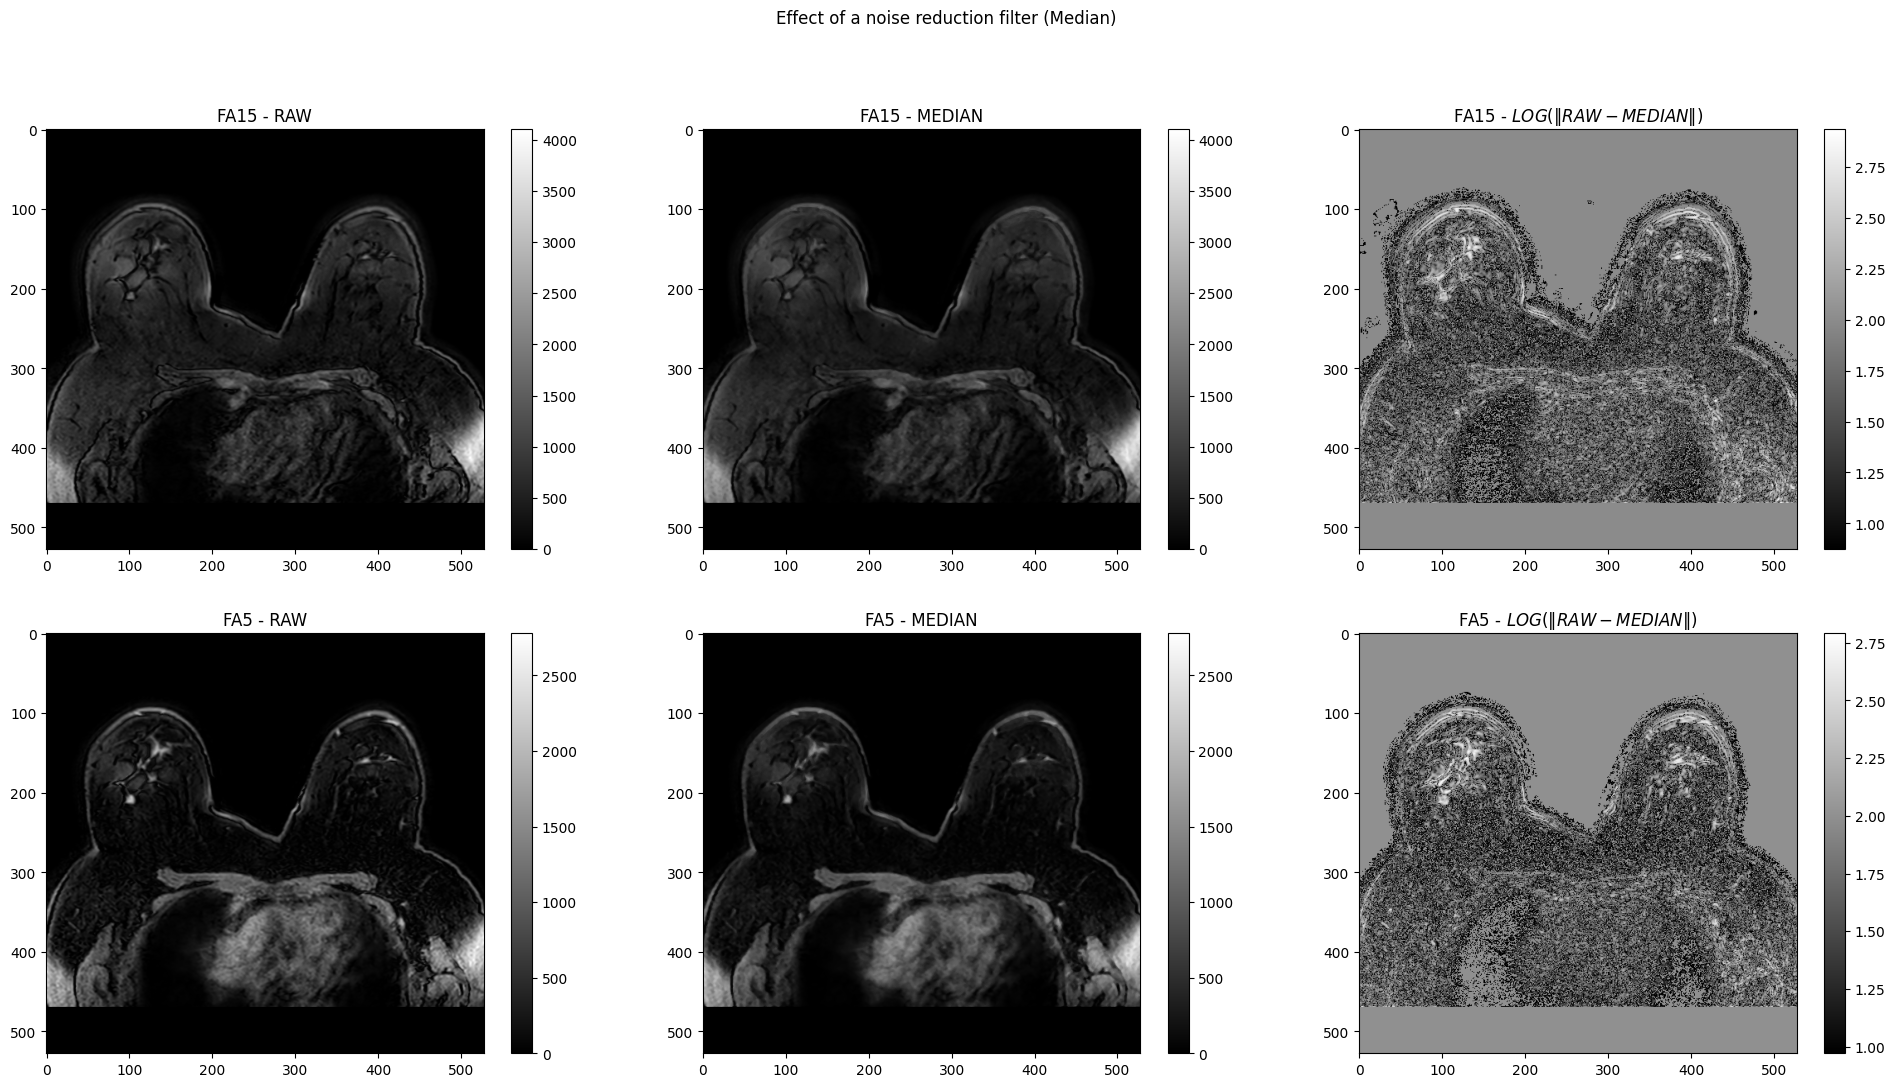

In [ ]:
nfigs = 6
ncols = 3#np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# fixed volumes colourmap
fixed_list = [htrdce_nparray_raw[tsp[-1], :, :], fixed_nparray_noise_red[tsp[-1], :, :]]
fixed_norm = colors.Normalize(vmin=np.min(fixed_list), vmax=np.max(fixed_list))

cbar[0] = axr[0].imshow(htrdce_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[0].set_title(f'{htrdce_sequence_pattern} - RAW')

cbar[1] = axr[1].imshow(fixed_nparray_noise_red[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[1].set_title(f'{htrdce_sequence_pattern} - MEDIAN')

cbar[2] = axr[2].imshow(fixed_noisereddiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[2].set_title(f'{htrdce_sequence_pattern} - ' + r'$LOG(\| RAW - MEDIAN \|)$')

# moving volumes colourmap
moving_list = [moving_nparray_raw[tsp[-1], :, :], moving_nparray_noise_red[tsp[-1], :, :]]
moving_norm = colors.Normalize(vmin=np.min(moving_list), vmax=np.max(moving_list))

cbar[3] = axr[3].imshow(moving_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[3].set_title(f'{moving_sequence_pattern} - RAW')

cbar[4] = axr[4].imshow(moving_nparray_noise_red[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[4].set_title(f'{moving_sequence_pattern} - MEDIAN')

cbar[5] = axr[5].imshow(moving_noisereddiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[5].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| RAW - MEDIAN \|)$')

fig.suptitle(f'Effect of a noise reduction filter ({noise_red_method.capitalize()})')
for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


#### NT4K Bias Correction

In [42]:

# TODO: Remember to uncomment the multi-levels in the nt4k_bias_correction
fixed_volume = nt4k_bias_correction(fixed_volume, simple=True)
fixed_nparray_nt4k = itk.GetArrayFromImage(fixed_volume)

moving_volume = nt4k_bias_correction(moving_volume, simple=True)
moving_nparray_nt4k = itk.GetArrayFromImage(moving_volume)

# Compare before and after NT4K correction (unregistered):
fixed_biasdiff = np.abs(np.log10(np.abs(fixed_nparray_noise_red - fixed_nparray_nt4k) + eps_zerodiv))
moving_biasdiff = np.abs(np.log10(np.abs(moving_nparray_noise_red - moving_nparray_nt4k) + eps_zerodiv))

print(f'Cell last run at {dtime.time(dtime.now())}')


Cell last run at 13:21:21.917510


##### Visual assessment of a Bias Correction in the Fixed and Moving Volumes

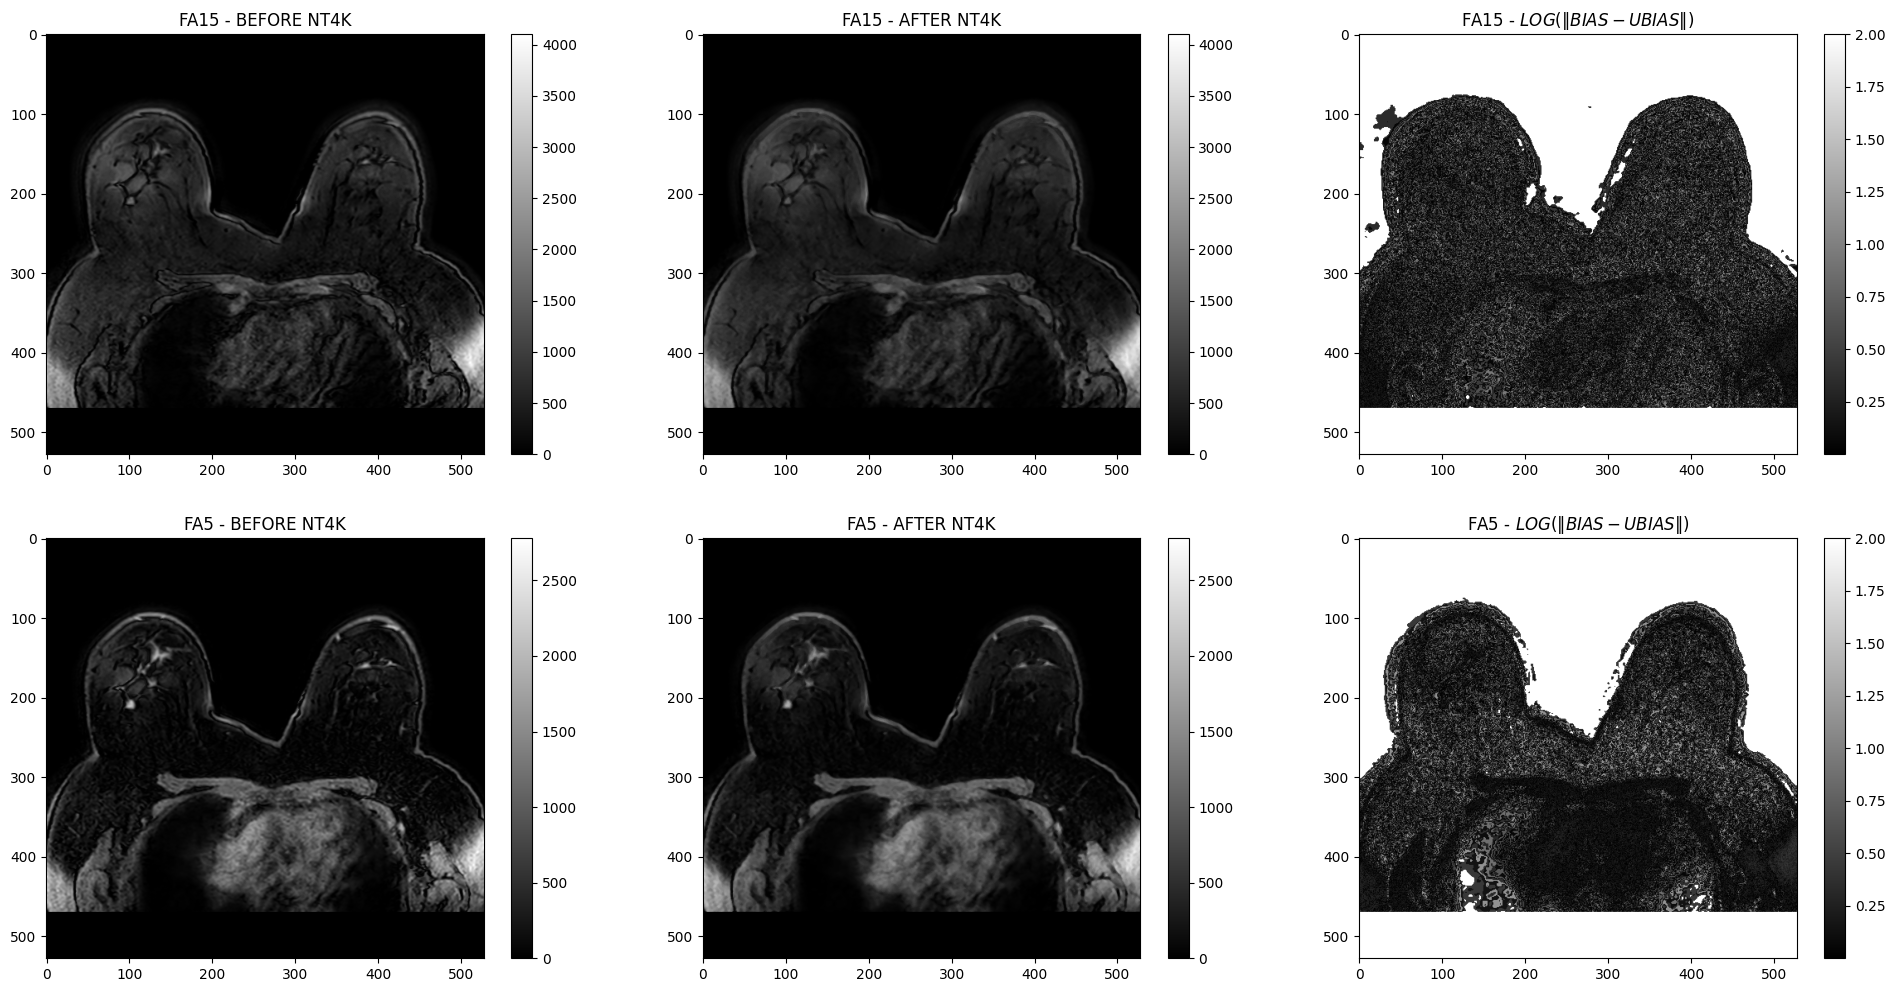

In [ ]:
nfigs = 6
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# fixed volumes colourmap
fixed_list = [htrdce_nparray_raw[tsp[-1], :, :], fixed_nparray_nt4k[tsp[-1], :, :]]
fixed_norm = colors.Normalize(vmin=np.min(fixed_list), vmax=np.max(fixed_list))

cbar[0] = axr[0].imshow(htrdce_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[0].set_title(f'{htrdce_sequence_pattern} - BEFORE NT4K')

cbar[1] = axr[1].imshow(fixed_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[1].set_title(f'{htrdce_sequence_pattern} - AFTER NT4K')

cbar[2] = axr[2].imshow(fixed_biasdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[2].set_title(f'{htrdce_sequence_pattern} - ' + r'$LOG(\| BIAS - UBIAS \|)$')


# fixed volumes colourmap
moving_list = [moving_nparray_raw[tsp[-1], :, :], moving_nparray_nt4k[tsp[-1], :, :]]
moving_norm = colors.Normalize(vmin=np.min(moving_list), vmax=np.max(moving_list))

cbar[3] = axr[3].imshow(moving_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[3].set_title(f'{moving_sequence_pattern} - BEFORE NT4K')

cbar[4] = axr[4].imshow(moving_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[4].set_title(f'{moving_sequence_pattern} - AFTER NT4K')

cbar[5] = axr[5].imshow(moving_biasdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[5].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| BIAS - UBIAS  \|)$')

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


#### Image Registration
To register the $T_1W$ images, I consider the acquisition with **FA=15degree** as the **Fixed** volume, because it has more PD-W, therefore has higher signal level 

In [ ]:
# Register using NT4K Corrected Volumes
moving_volume_reg, result_transform_parameters = itk.elastix_registration_method(
    fixed_volume, moving_volume,
    parameter_object=parameter_object,
    log_to_console=False)

# Register using bias-uncorrected Volumes
moving_volume_reg_noNT4K, result_transform_parameters_noNT4K = itk.elastix_registration_method(
    htrdce_volume_raw, moving_volume_raw,
    parameter_object=parameter_object,
    log_to_console=False)

moving_nparray_reg = itk.GetArrayFromImage(moving_volume_reg)
moving_nparray_reg_noNT4K = itk.GetArrayFromImage(moving_volume_reg_noNT4K)

# itk.imwrite(moving_volume_reg, os.path.join(REGPATH, f'moving_{moving_sequence_pattern}_reg.nii.gz'))
# itk.imwrite(moving_volume_reg_noNT4K, os.path.join(REGPATH, f'moving_{moving_sequence_pattern}_reg_noNT4K.nii.gz'))


##### Visual assessment of the Registration Effect

In [45]:
# Compare before and after registration and NT4K correction (only on moving volume):
moving_bias_regdiff = np.abs(np.log10(np.abs(moving_nparray_nt4k - moving_nparray_reg)+eps_zerodiv))
moving_ureg_biasdiff = moving_biasdiff.copy()
moving_reg_biassdiff = np.abs(np.log10(np.abs(moving_nparray_reg - moving_nparray_reg_noNT4K) + eps_zerodiv))
moving_ubias_regdiff = np.abs(np.log10(np.abs(moving_nparray_raw - moving_nparray_reg_noNT4K) + eps_zerodiv))


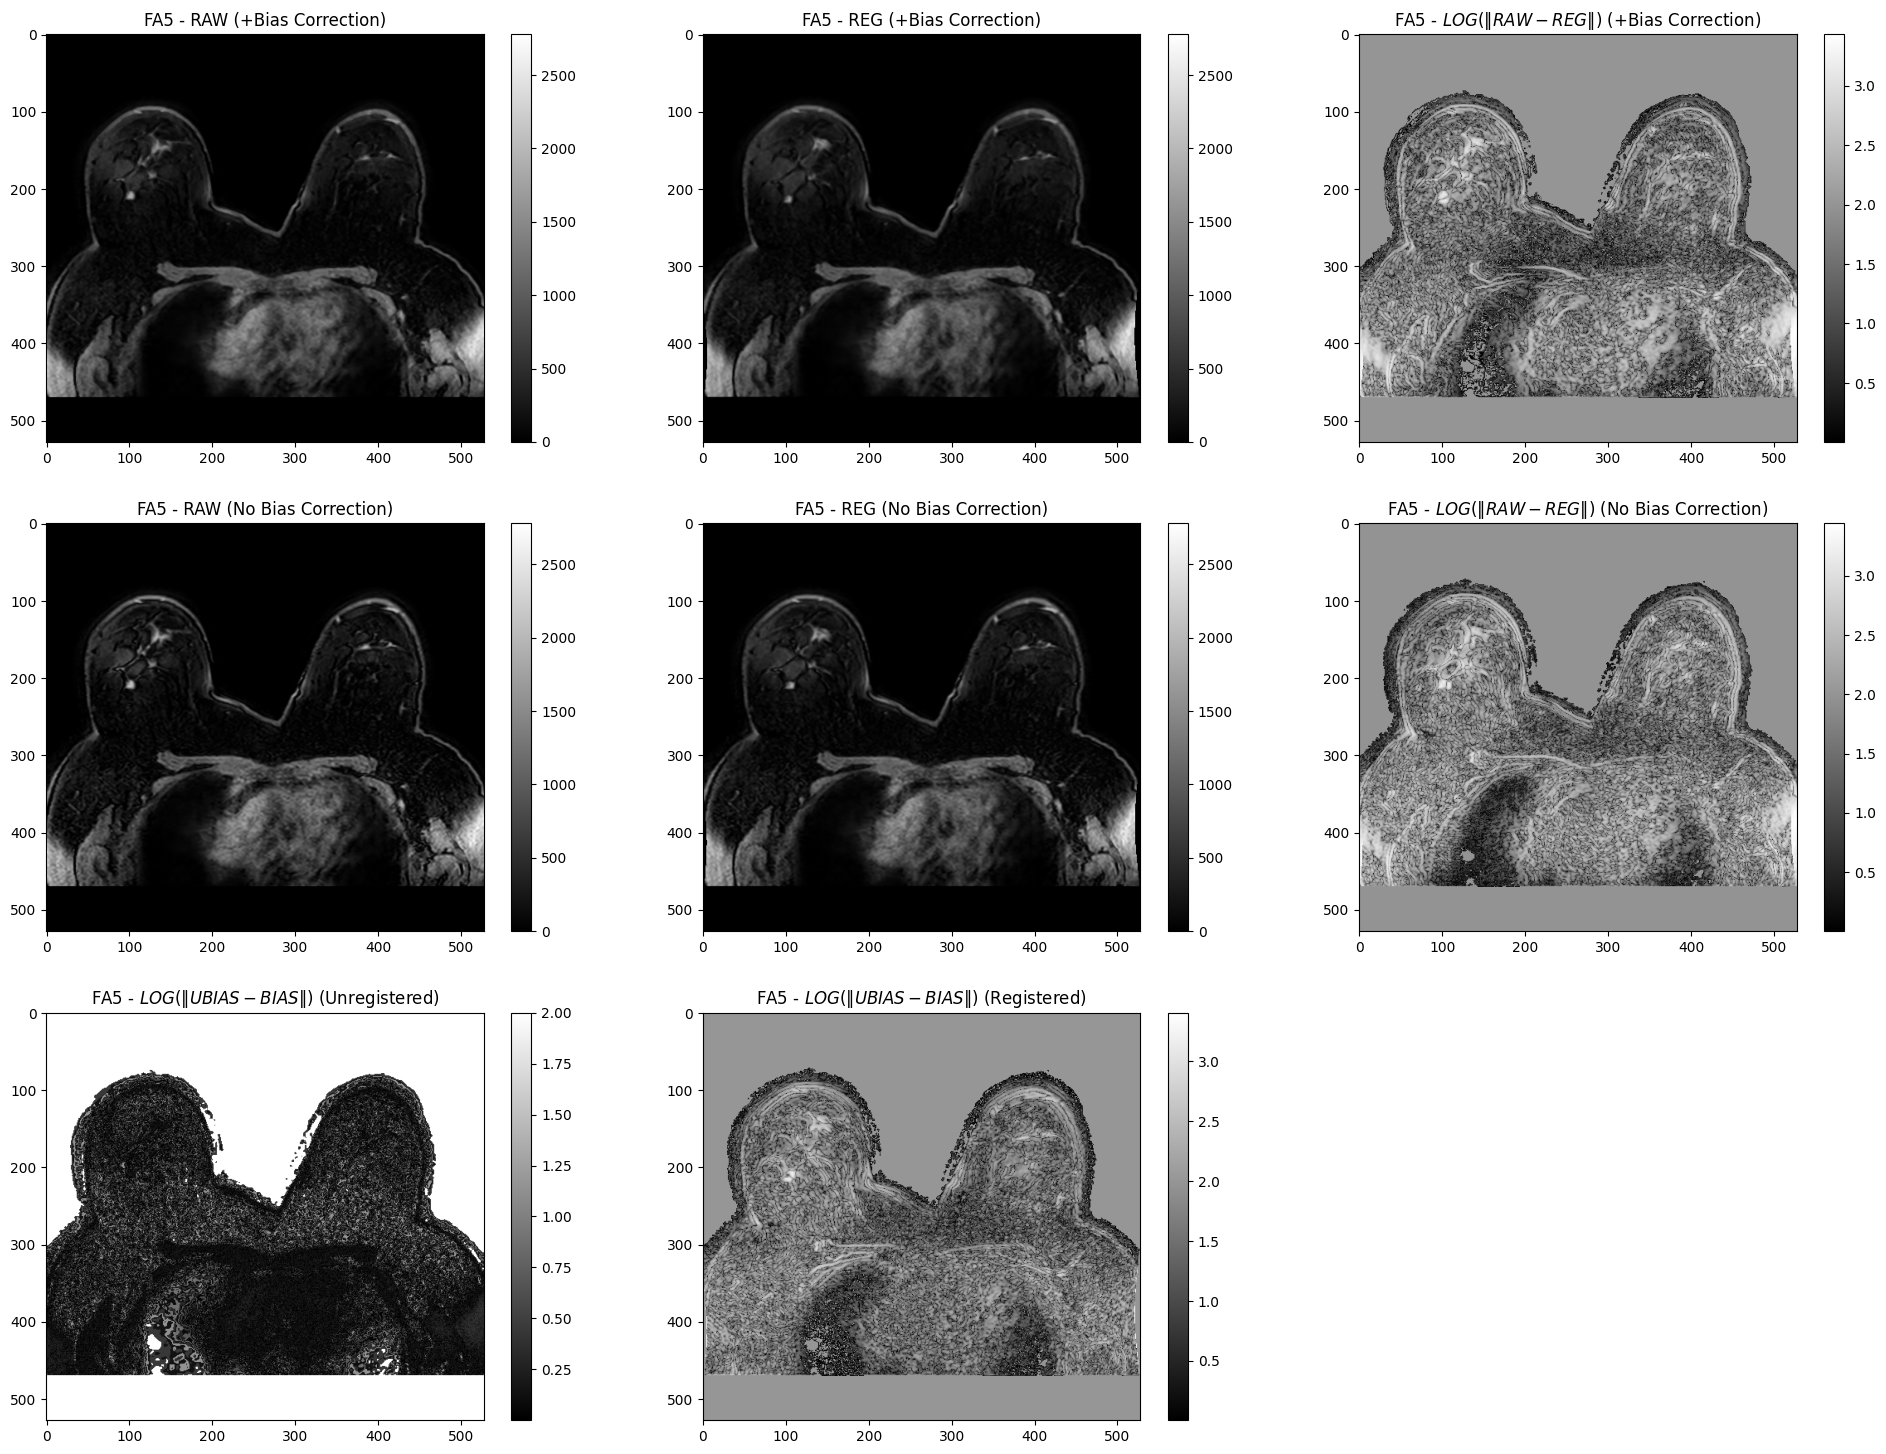

In [46]:
nfigs = 9
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# moving volumes colourmap
moving_list = [moving_nparray_raw[tsp[-1], :, :], moving_nparray_nt4k[tsp[-1], :, :], 
               moving_nparray_reg[tsp[-1], :, :], moving_nparray_reg_noNT4K[tsp[-1], :, :]]
moving_norm = colors.Normalize(vmin=np.min(moving_list), vmax=np.max(moving_list))

# Unregistered + Bias Correction, i.e. BIAS_UREG
cbar[0] = axr[0].imshow(moving_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[0].set_title(f'{moving_sequence_pattern} - RAW (+Bias Correction)')

# Registered + No Bias Correction, i.e. BIAS_REG
cbar[1] = axr[1].imshow(moving_nparray_reg[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[1].set_title(f'{moving_sequence_pattern} - REG (+Bias Correction)')

cbar[2] = axr[2].imshow(moving_bias_regdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[2].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| RAW - REG \|)$ (+Bias Correction)')



# Unregistered + No Bias Correction, i.e. UBIAS_UREG
cbar[3] = axr[3].imshow(moving_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[3].set_title(f'{moving_sequence_pattern} - RAW (No Bias Correction)')

# Registered + No Bias Correction, i.e. UBIAS_REG
cbar[4] = axr[4].imshow(moving_nparray_reg_noNT4K[tsp[-1],:,:], cmap='gray', aspect='auto', norm=moving_norm)
axr[4].set_title(f'{moving_sequence_pattern} - REG (No Bias Correction)')

cbar[5] = axr[5].imshow(moving_ubias_regdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[5].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| RAW - REG \|)$ (No Bias Correction)')


# Unregistered - Effect of Bias Correction, i.e. UREG_BIASDIFF
cbar[6] = axr[6].imshow(moving_ureg_biasdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[6].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| UBIAS - BIAS \|)$ (Unregistered)')

# Registered + No Bias Correction, i.e. REG_BIASDIFF
cbar[7] = axr[7].imshow(moving_reg_biassdiff[tsp[-1],:,:], cmap='gray', aspect='auto')
axr[7].set_title(f'{moving_sequence_pattern} - ' + r'$LOG(\| UBIAS - BIAS \|)$ (Registered)')

axr[8].remove()

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


##### Level of motion correction and agreement with target volume

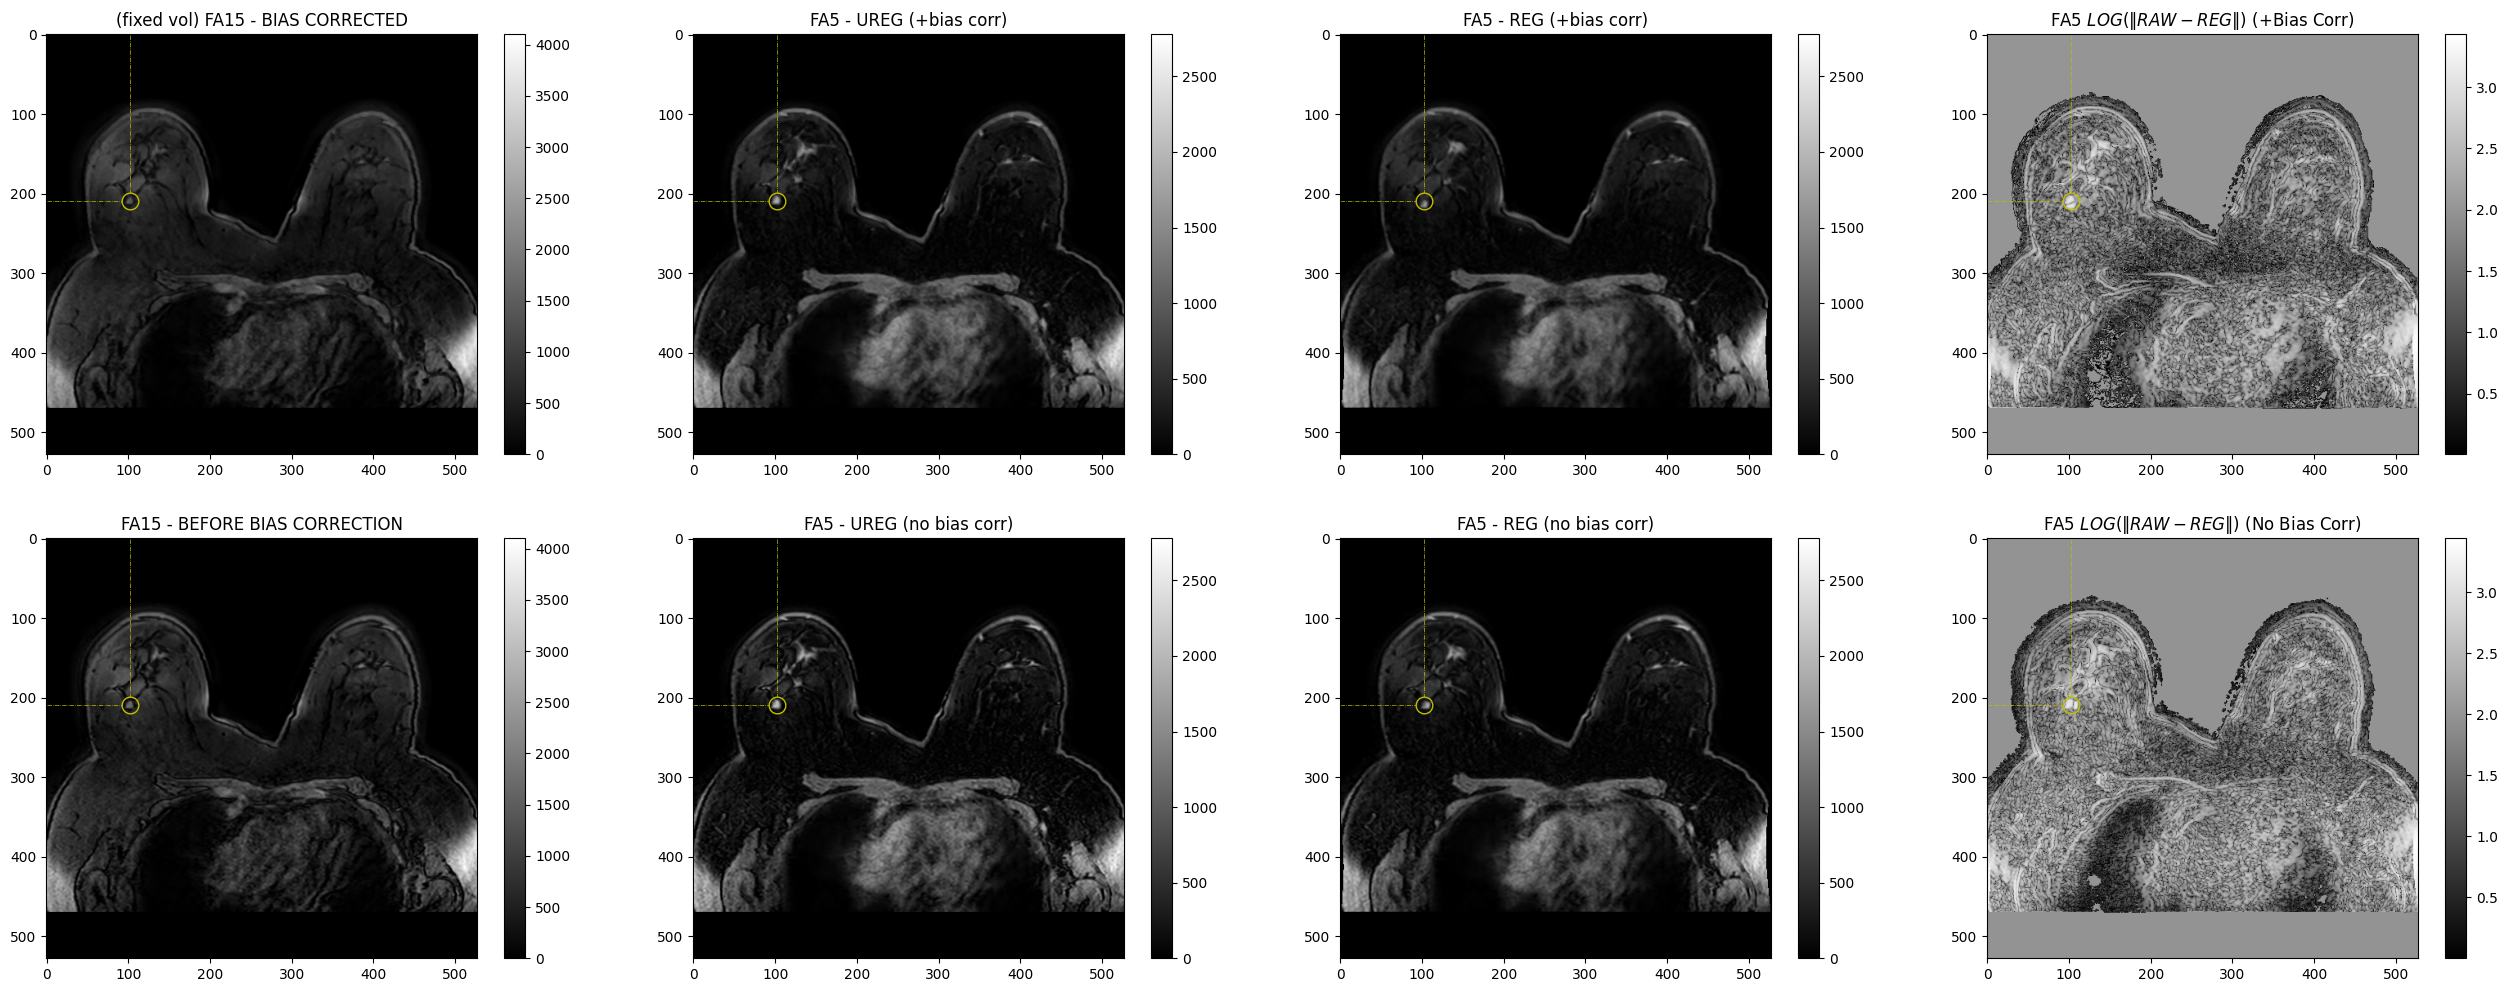

In [ ]:
# Check level of motion between both FA
nfigs = 8
ncols = 4 # np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# fixed volumes colourmap
fixed_list = [fixed_nparray_nt4k[tsp[-1], :, :], htrdce_nparray_raw[tsp[-1], :, :]]
fixed_norm = colors.Normalize(vmin=np.min(fixed_list), vmax=np.max(fixed_list))

cbar[0] = axr[0].imshow(fixed_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[0].set_title(f'(fixed vol) {htrdce_sequence_pattern} - BIAS CORRECTED')
axr[0].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[0].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[0].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[4] = axr[4].imshow(htrdce_nparray_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fixed_norm)
axr[4].set_title(f'{htrdce_sequence_pattern} - BEFORE BIAS CORRECTION')
axr[4].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[4].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[4].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')


# moving volumes colourmap
moving_list = [moving_nparray_raw[tsp[-1], :, :], moving_nparray_nt4k[tsp[-1], :, :], 
               moving_nparray_reg[tsp[-1], :, :], moving_nparray_reg_noNT4K[tsp[-1], :, :]]
moving_norm = colors.Normalize(vmin=np.min(moving_list), vmax=np.max(moving_list))

cbar[1] = axr[1].imshow(moving_nparray_nt4k[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[1].set_title(f'{moving_sequence_pattern} - UREG (+bias corr)')
axr[1].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[1].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[1].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[2] = axr[2].imshow(moving_nparray_reg[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[2].set_title(f'{moving_sequence_pattern} - REG (+bias corr)')
axr[2].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[2].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[2].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[3] = axr[3].imshow(moving_bias_regdiff[tsp[-1], :, :], cmap='gray', aspect='auto')
axr[3].set_title(f'{moving_sequence_pattern} ' + r'$LOG(\| RAW - REG \|)$ (+Bias Corr)')
axr[3].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[3].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[3].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[5] = axr[5].imshow(moving_nparray_raw[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[5].set_title(f'{moving_sequence_pattern} - UREG (no bias corr)')
axr[5].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[5].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[5].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[6] = axr[6].imshow(moving_nparray_reg_noNT4K[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[6].set_title(f'{moving_sequence_pattern} - REG (no bias corr)')
axr[6].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[6].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[6].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')

cbar[7] = axr[7].imshow(moving_ubias_regdiff[tsp[-1], :, :], cmap='gray', aspect='auto')
axr[7].set_title(f'{moving_sequence_pattern} ' + r'$LOG(\| RAW - REG \|)$ (No Bias Corr)')
axr[7].plot([tsp[0]]*2, [0, tsp[1]-10], 'y-.', linewidth=0.5)
axr[7].plot([0, tsp[0]-10], [tsp[1]]*2, 'y-.', linewidth=0.5)
axr[7].plot(tsp[0], tsp[1], 'yo', markersize=12, fillstyle='none')


for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])



## Estimate T1 map

First, I need to assess the effect of bias correction and registration in the fitting quality



### 2 Flip Angles

In [ ]:
# T1 mapping parameters
alfa_i = [5, 15]
flip_angles = {
    'reg_bias_images': [moving_nparray_reg, fixed_nparray_nt4k],
    'ureg_bias_images': [moving_nparray_nt4k, fixed_nparray_nt4k],
    'reg_ubias_images': [moving_nparray_reg_noNT4K, htrdce_nparray_raw],
    'ureg_ubias_images': [moving_nparray_raw, htrdce_nparray_raw],
    'deg': alfa_i,
    'rad': np.deg2rad(alfa_i)}

T1lb, T1ub = [200.0, 5000.0]

bin_hist = np.linspace(0.8 * T1lb, 0.8 * T1ub, num=256)
histtype = 'step' # {'bar', 'barstacked', 'step', 'stepfilled'}, default: 'bar'

df_index = ['REGBIAS', 'UREGBIAS', 'REGUBIAS', 'UREGUBIAS']
t1_assessment_results = {'Rational Linear': ['']*len(df_index), 
                         'Standard Linear 2FA': ['']*len(df_index), 
                         'Standard Linear 3FA': ['']*len(df_index), 
                         'Nonlinear 3FA': ['']*len(df_index) 
                         }
# m0_assessment_results = {'Rational Linear': ['']*len(df_index), 
#                          'Standard Linear 2FA': ['']*len(df_index), 
#                          'Standard Linear 3FA': ['']*len(df_index), 
#                          'Nonlinear 3FA': ['']*len(df_index) 
#                          }


#### Rational Linear Fit
$$
\hat{T_1} = 2T_R \frac{\frac{S_1}{\alpha_1} - \frac{S_2}{\alpha_2}}{S_2\alpha_2 - S_1\alpha_1}
$$
$$
\hat{M_0} = S_1S_2 \frac{\frac{\alpha_2}{\alpha_1} - \frac{\alpha_1}{\alpha_2}}{S_2\alpha_2 - S_1\alpha_1}
$$

In [49]:
T1map_reg_bias_rlfit, M0map_reg_bias_rlfit = t1fit_vfa(flip_angles['reg_bias_images'], 
                                           flip_angles['deg'], 
                                           {'TR': float(patient_metadata['RepetitionTime'])}, 
                                           FitAlgo = 'rational_linear',
                                           T1ub=T1ub, T1lb=T1lb)
T1map_ureg_bias_rlfit, M0map_ureg_bias_rlfit = t1fit_vfa(flip_angles['ureg_bias_images'], 
                                             flip_angles['deg'], 
                                             {'TR': float(patient_metadata['RepetitionTime'])}, 
                                             FitAlgo = 'rational_linear',
                                             T1ub=T1ub, T1lb=T1lb)
T1map_reg_ubias_rlfit, M0map_reg_ubias_rlfit = t1fit_vfa(flip_angles['reg_ubias_images'], 
                                             flip_angles['deg'], 
                                             {'TR': float(patient_metadata['RepetitionTime'])}, 
                                             FitAlgo = 'rational_linear',
                                             T1ub=T1ub, T1lb=T1lb)
T1map_ureg_ubias_rlfit, M0map_ureg_ubias_rlfit = t1fit_vfa(flip_angles['ureg_ubias_images'], 
                                               flip_angles['deg'], 
                                               {'TR': float(patient_metadata['RepetitionTime'])}, 
                                               FitAlgo = 'rational_linear',
                                               T1ub=T1ub, T1lb=T1lb)

T1diff_reg_biasdiff_rlfit = np.abs(np.log10(np.abs(T1map_reg_bias_rlfit - T1map_reg_ubias_rlfit) + eps_zerodiv))
T1diff_ureg_biasdiff_rlfit = np.abs(np.log10(np.abs(T1map_ureg_bias_rlfit - T1map_ureg_ubias_rlfit) + eps_zerodiv))
T1diff_bias_regdiff_rlfit = np.abs(np.log10(np.abs(T1map_reg_bias_rlfit - T1map_ureg_bias_rlfit) + eps_zerodiv))
T1diff_ubias_regdiff_rlfit = np.abs(np.log10(np.abs(T1map_ureg_ubias_rlfit - T1map_reg_ubias_rlfit) + eps_zerodiv))

print('Estimated T1 values for the different tests (average over a small roi centred in the point:')
T1val_reg_bias = np.nanmedian(T1map_reg_bias_rlfit[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Rational Linear'][df_index.index('REGBIAS')] = T1val_reg_bias
# m0dict1d_results['Rational Linear'] = m0_1D_rationalLinFit.flatten()

T1val_ureg_bias = np.nanmedian(T1map_ureg_bias_rlfit[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Rational Linear'][df_index.index('UREGBIAS')] = T1val_ureg_bias

T1val_reg_ubias = np.nanmedian(T1map_reg_ubias_rlfit[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Rational Linear'][df_index.index('REGUBIAS')] = T1val_reg_ubias

T1val_ureg_ubias = np.nanmedian(T1map_ureg_ubias_rlfit[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Rational Linear'][df_index.index('UREGUBIAS')] = T1val_ureg_ubias

print('\tREG\t\tUREG')
print(f'BIAS\t{T1val_reg_bias:.2f}[ms]\t\t{T1val_ureg_bias:.2f}[ms]')
print(f'UBIAS\t{T1val_reg_ubias:.2f}[ms]\t\t{T1val_ureg_ubias:.2f}[ms]')


Estimated T1 values for the different tests (average over a small roi centred in the point:
	REG		UREG
BIAS	108.70[ms]		808.73[ms]
UBIAS	0.00[ms]		706.49[ms]


#### Standard Linear Fit
$$ \frac{S_i}{\sin(\alpha_i)} = E_1\frac{S_i}{\tan(\alpha_i)} + M_0(1-E_1) $$
$$ \hat{Y}[i] = m\hat{X}[i] + n $$

with: $ \hat{Y}[i] = \frac{S_i}{\sin(\alpha_i)} $; $ \hat{X}[i] = \frac{S_i}{\tan(\alpha_i)} $ ; $ m = E_1 $; $ n = M_0(1-E1) $



In [50]:
T1map_reg_bias_stdlfit2fa, M0map_reg_bias_stdlfit2fa = t1fit_vfa(flip_angles['reg_bias_images'], 
                                           flip_angles['deg'], 
                                           {'TR': float(patient_metadata['RepetitionTime'])}, 
                                           FitAlgo = 'std_linear',
                                           T1ub=T1ub, T1lb=T1lb)
T1map_ureg_bias_stdlfit2fa, M0map_ureg_bias_stdlfit2fa = t1fit_vfa(flip_angles['ureg_bias_images'], 
                                             flip_angles['deg'], 
                                             {'TR': float(patient_metadata['RepetitionTime'])}, 
                                             FitAlgo = 'std_linear',
                                             T1ub=T1ub, T1lb=T1lb)
T1map_reg_ubias_stdlfit2fa, M0map_reg_ubias_stdlfit2fa = t1fit_vfa(flip_angles['reg_ubias_images'], 
                                             flip_angles['deg'], 
                                             {'TR': float(patient_metadata['RepetitionTime'])}, 
                                             FitAlgo = 'std_linear',
                                             T1ub=T1ub, T1lb=T1lb)
T1map_ureg_ubias_stdlfit2fa, M0map_ureg_ubias_stdlfit2fa = t1fit_vfa(flip_angles['ureg_ubias_images'], 
                                               flip_angles['deg'], 
                                               {'TR': float(patient_metadata['RepetitionTime'])}, 
                                               FitAlgo = 'std_linear',
                                               T1ub=T1ub, T1lb=T1lb)

T1diff_reg_biasdiff_stdlfit2fa = np.abs(np.log10(np.abs(T1map_reg_bias_stdlfit2fa - T1map_reg_ubias_stdlfit2fa) + eps_zerodiv))
T1diff_ureg_biasdiff_stdlfit2fa = np.abs(np.log10(np.abs(T1map_ureg_bias_stdlfit2fa - T1map_ureg_ubias_stdlfit2fa) + eps_zerodiv))
T1diff_bias_regdiff_stdlfit2fa = np.abs(np.log10(np.abs(T1map_reg_bias_stdlfit2fa - T1map_ureg_bias_stdlfit2fa) + eps_zerodiv))
T1diff_ubias_regdiff_stdlfit2fa = np.abs(np.log10(np.abs(T1map_ureg_ubias_stdlfit2fa - T1map_reg_ubias_stdlfit2fa) + eps_zerodiv))

print('Estimated T1 values for the different tests (average over a small roi centred in the point:')
T1val_reg_bias = np.nanmedian(T1map_reg_bias_stdlfit2fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 2FA'][df_index.index('REGBIAS')] = T1val_reg_bias
# m0dict1d_results['Standard Linear 2FA'] = m0_1D_rationalLinFit.flatten()

T1val_ureg_bias = np.nanmedian(T1map_ureg_bias_stdlfit2fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 2FA'][df_index.index('UREGBIAS')] = T1val_ureg_bias

T1val_reg_ubias = np.nanmedian(T1map_reg_ubias_stdlfit2fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 2FA'][df_index.index('REGUBIAS')] = T1val_reg_ubias

T1val_ureg_ubias = np.nanmedian(T1map_ureg_ubias_stdlfit2fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 2FA'][df_index.index('UREGUBIAS')] = T1val_ureg_ubias

print('\tREG\t\tUREG')
# print(f'BIAS\t--[ms]\t\t{T1val_ureg_bias:.2f}[ms]')
# print(f'UBIAS\t--[ms]\t\t{T1val_ureg_ubias:.2f}[ms]')
print(f'BIAS\t{T1val_reg_bias:.2f}[ms]\t\t{T1val_ureg_bias:.2f}[ms]')
print(f'UBIAS\t{T1val_reg_ubias:.2f}[ms]\t\t{T1val_ureg_ubias:.2f}[ms]')


invalid value encountered in log


Estimated T1 values for the different tests (average over a small roi centred in the point:
	REG		UREG
BIAS	108.34[ms]		801.73[ms]
UBIAS	0.00[ms]		700.79[ms]


#### Nonlinear Fit

There is no point in analysing it with 2 Flip Angles, as shown by the simulations, the results should be almost the same as the standard linear approximation.

Leave the resources for the 3 Flip angles analysis

#### Visual Assessment of the Results


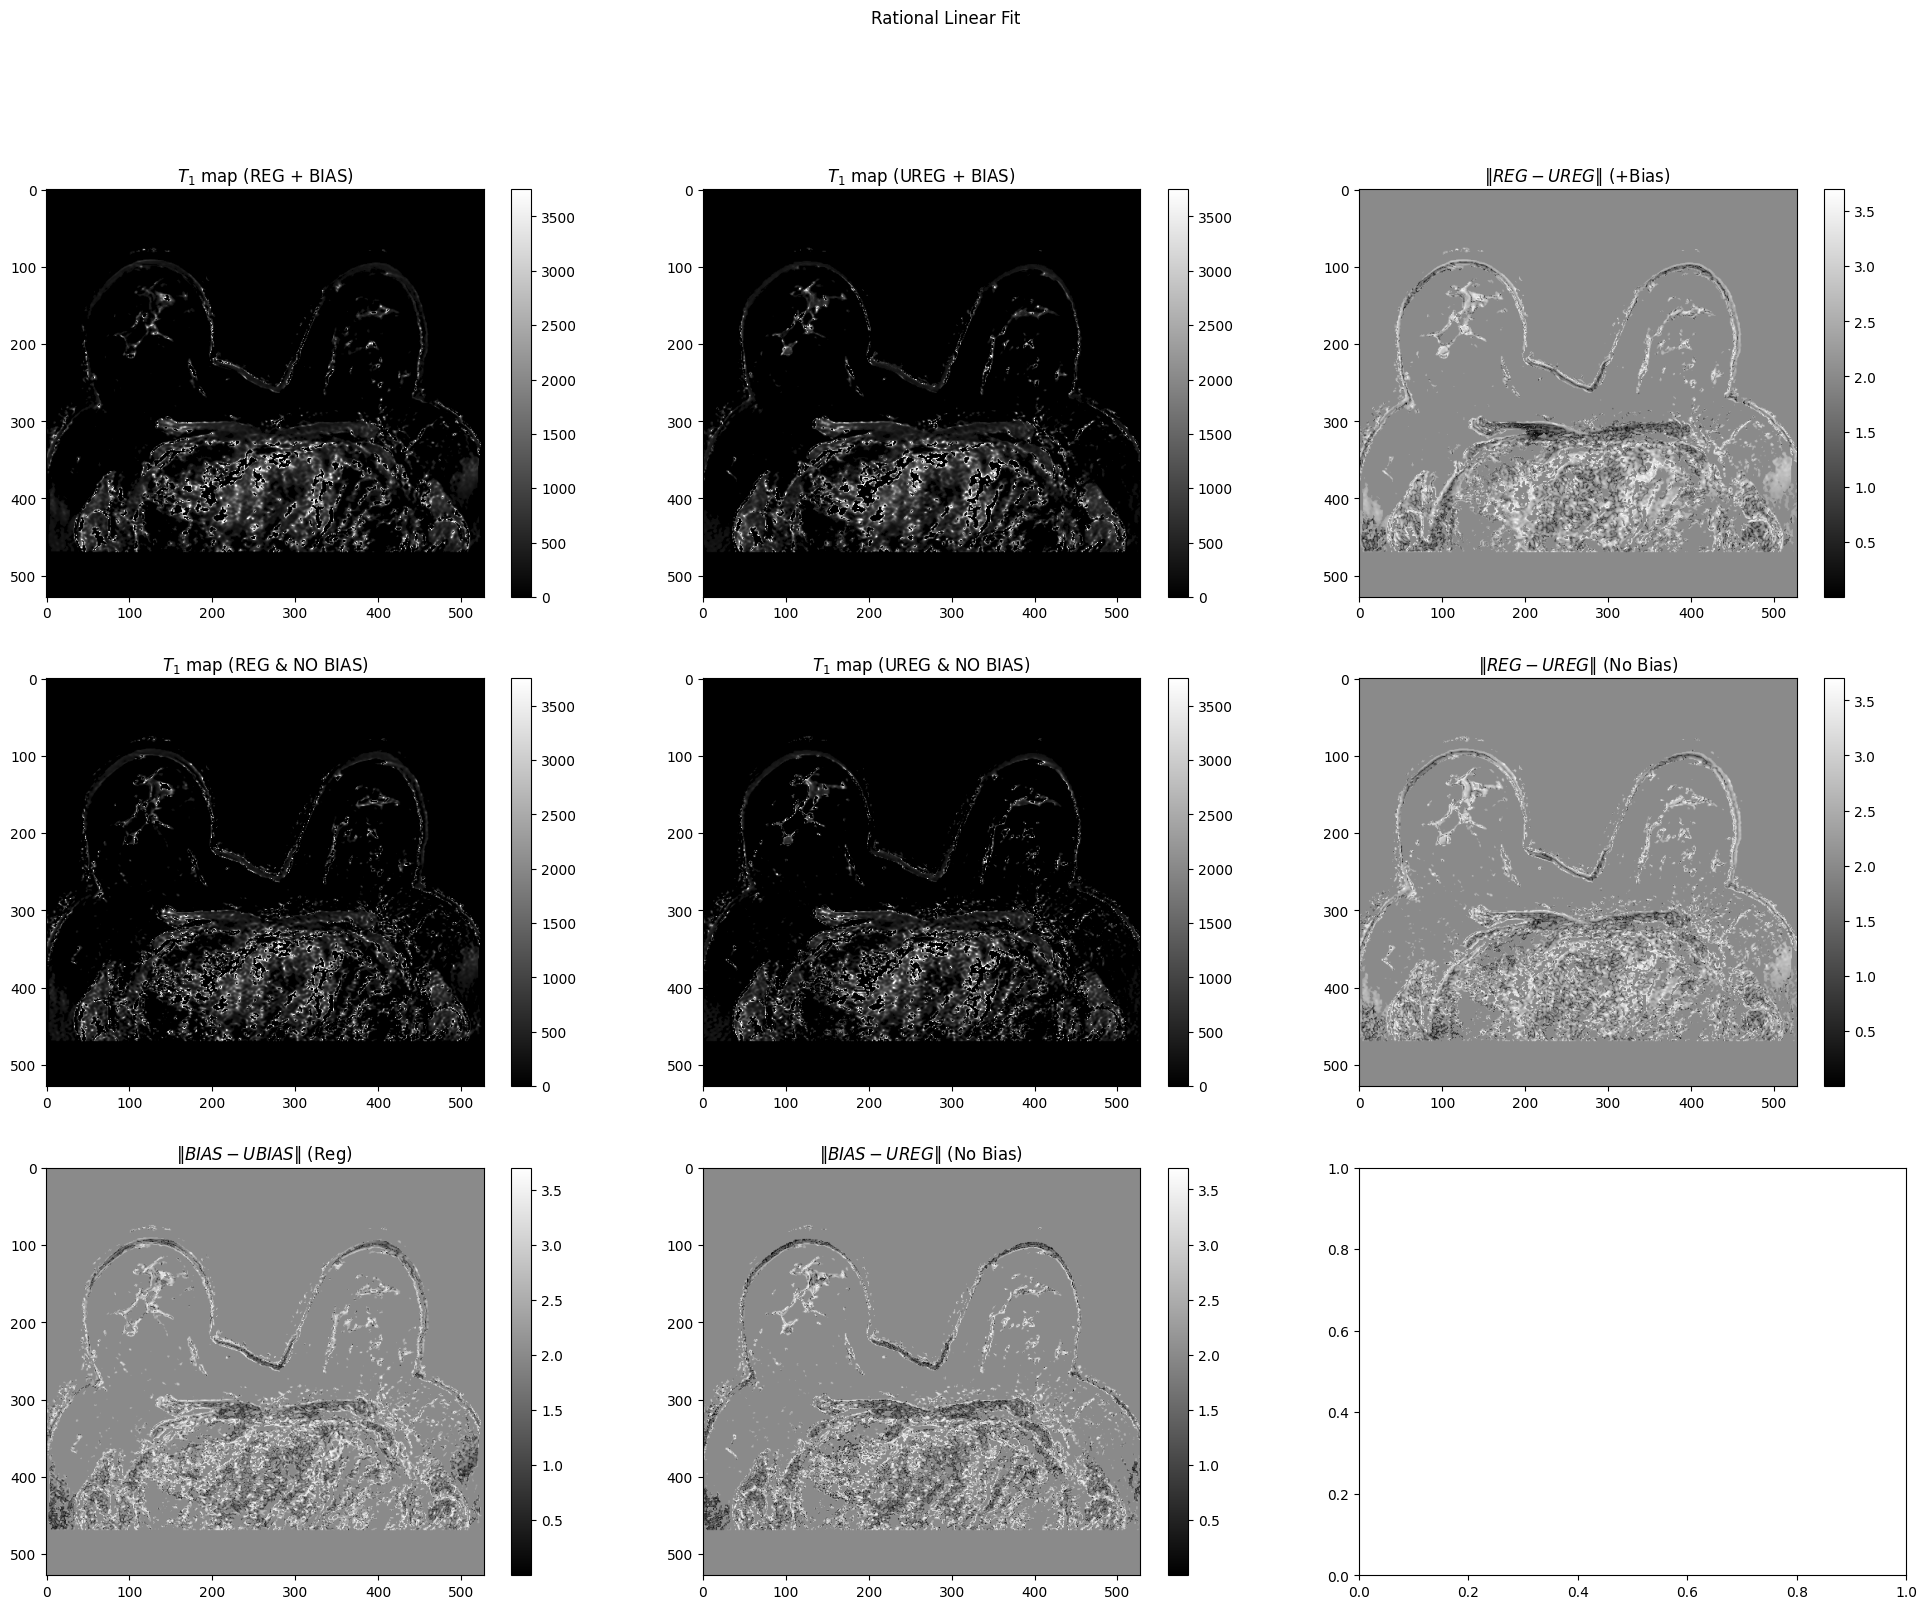

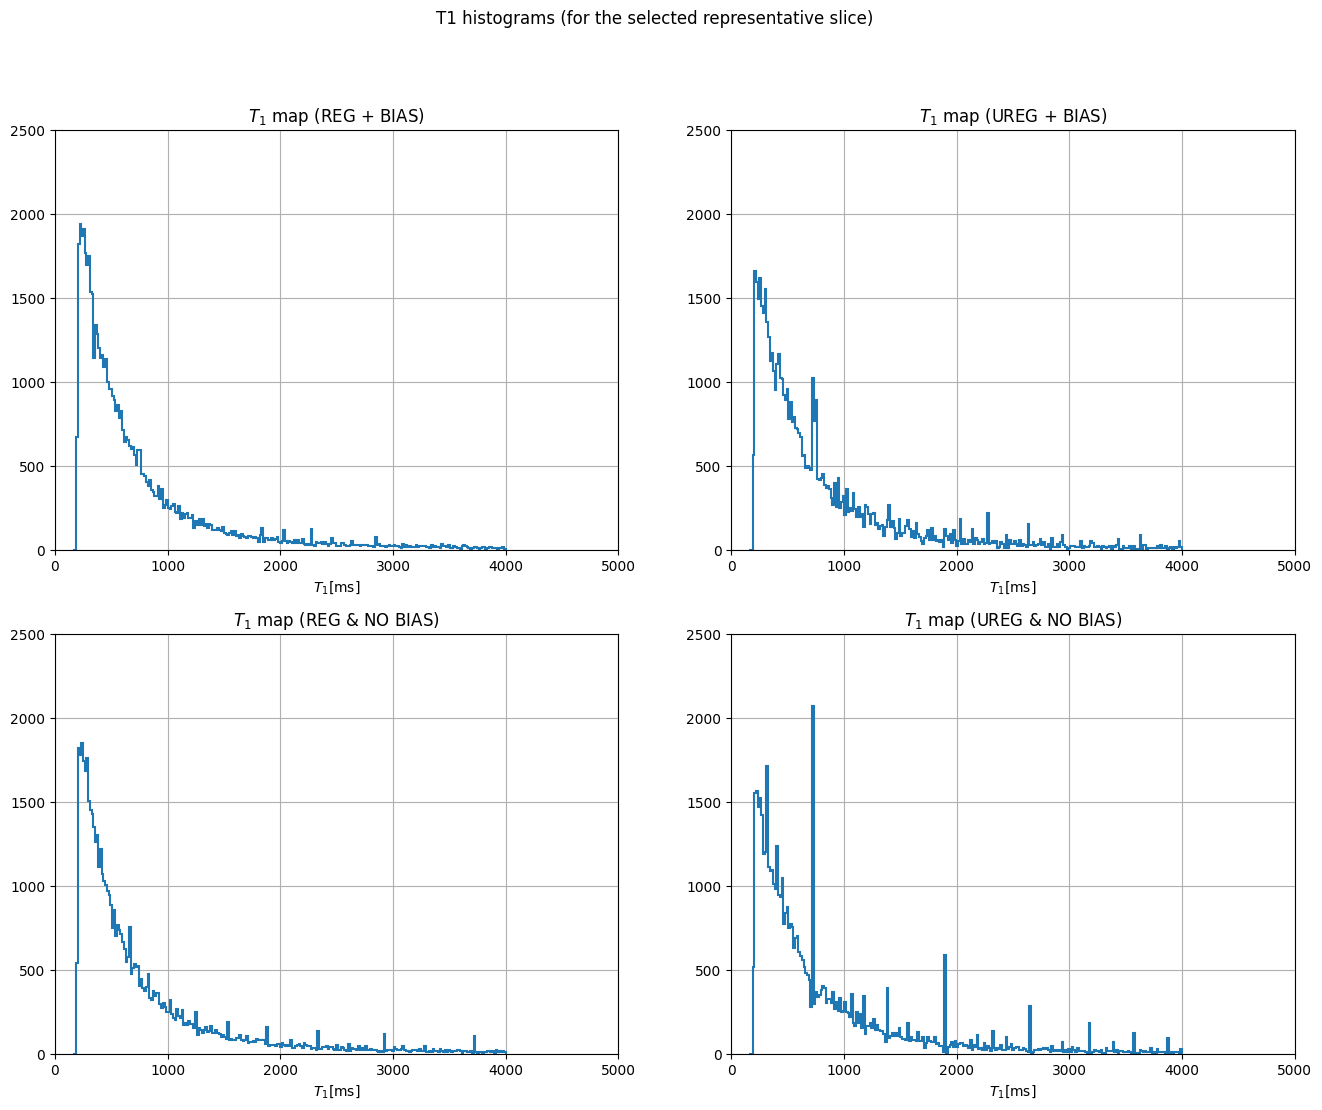

In [51]:
# Rational Linear Fit - Registration & Bias correction 
nfigs = 9
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# T1map volumes colourmap
t1map_list = [T1map_reg_bias_rlfit[tsp[-1], :, :], T1map_ureg_bias_rlfit[tsp[-1], :, :],
              T1map_reg_ubias_rlfit[tsp[-1], :, :], T1map_ureg_ubias_rlfit[tsp[-1], :, :]]
t1map_norm = colors.Normalize(vmin=np.min(t1map_list), vmax=0.75*np.max(t1map_list))

cbar[0] = axr[0].imshow(T1map_reg_bias_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[0].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[0].set_title(r'$T_1$ map (REG + BIAS)')

cbar[1] = axr[1].imshow(T1map_ureg_bias_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[1].set_title(r'$T_1$ map (UREG + BIAS)')

cbar[2] = axr[2].imshow(T1diff_bias_regdiff_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[2].set_title(r'$\|REG - UREG\|$ (+Bias)')

cbar[3] = axr[3].imshow(T1map_reg_ubias_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[3].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[3].set_title(r'$T_1$ map (REG & NO BIAS)')

cbar[4] = axr[4].imshow(T1map_ureg_ubias_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[4].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[4].set_title(r'$T_1$ map (UREG & NO BIAS)')

cbar[5] = axr[5].imshow(T1diff_ubias_regdiff_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[5].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[5].set_title(r'$\|REG - UREG\|$ (No Bias)')

cbar[6] = axr[6].imshow(T1diff_reg_biasdiff_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[6].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[6].set_title(r'$\|BIAS - UBIAS\|$ (Reg)')

cbar[7] = axr[7].imshow(T1diff_ureg_biasdiff_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[7].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[7].set_title(r'$\|BIAS - UREG\|$ (No Bias)')


for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])
fig.suptitle('Rational Linear Fit')

# Display the histograms
nfigs = 4
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()

_, _, bar_container = axr[0].hist(T1map_reg_bias_rlfit[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[0].set_title(r'$T_1$ map (REG + BIAS)')
axr[0].set_xlabel(r'$T_1$[ms]')
hist_max = bar_container[0].get_xy()[:,1].max()

_, _, bar_container = axr[1].hist(T1map_ureg_bias_rlfit[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[1].set_title(r'$T_1$ map (UREG + BIAS)')
axr[1].set_xlabel(r'$T_1$[ms]')
hist_max = np.max([hist_max, bar_container[0].get_xy()[:,1].max()])
                  
_, _, bar_container = axr[2].hist(T1map_reg_ubias_rlfit[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[2].set_title(r'$T_1$ map (REG & NO BIAS)')
axr[2].set_xlabel(r'$T_1$[ms]')
hist_max = np.max([hist_max, bar_container[0].get_xy()[:,1].max()])

_, _, bar_container = axr[3].hist(T1map_ureg_ubias_rlfit[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[3].set_title(r'$T_1$ map (UREG & NO BIAS)')
_ = axr[3].set_xlabel(r'$T_1$[ms]')
hist_max = np.ceil(np.max([hist_max, bar_container[0].get_xy()[:,1].max()])/500) * 500

fig.suptitle('T1 histograms (for the selected representative slice)')

for idx in range(4):
    axr[idx].axis([0.0, T1ub, 0.0, hist_max])
    axr[idx].grid(True)



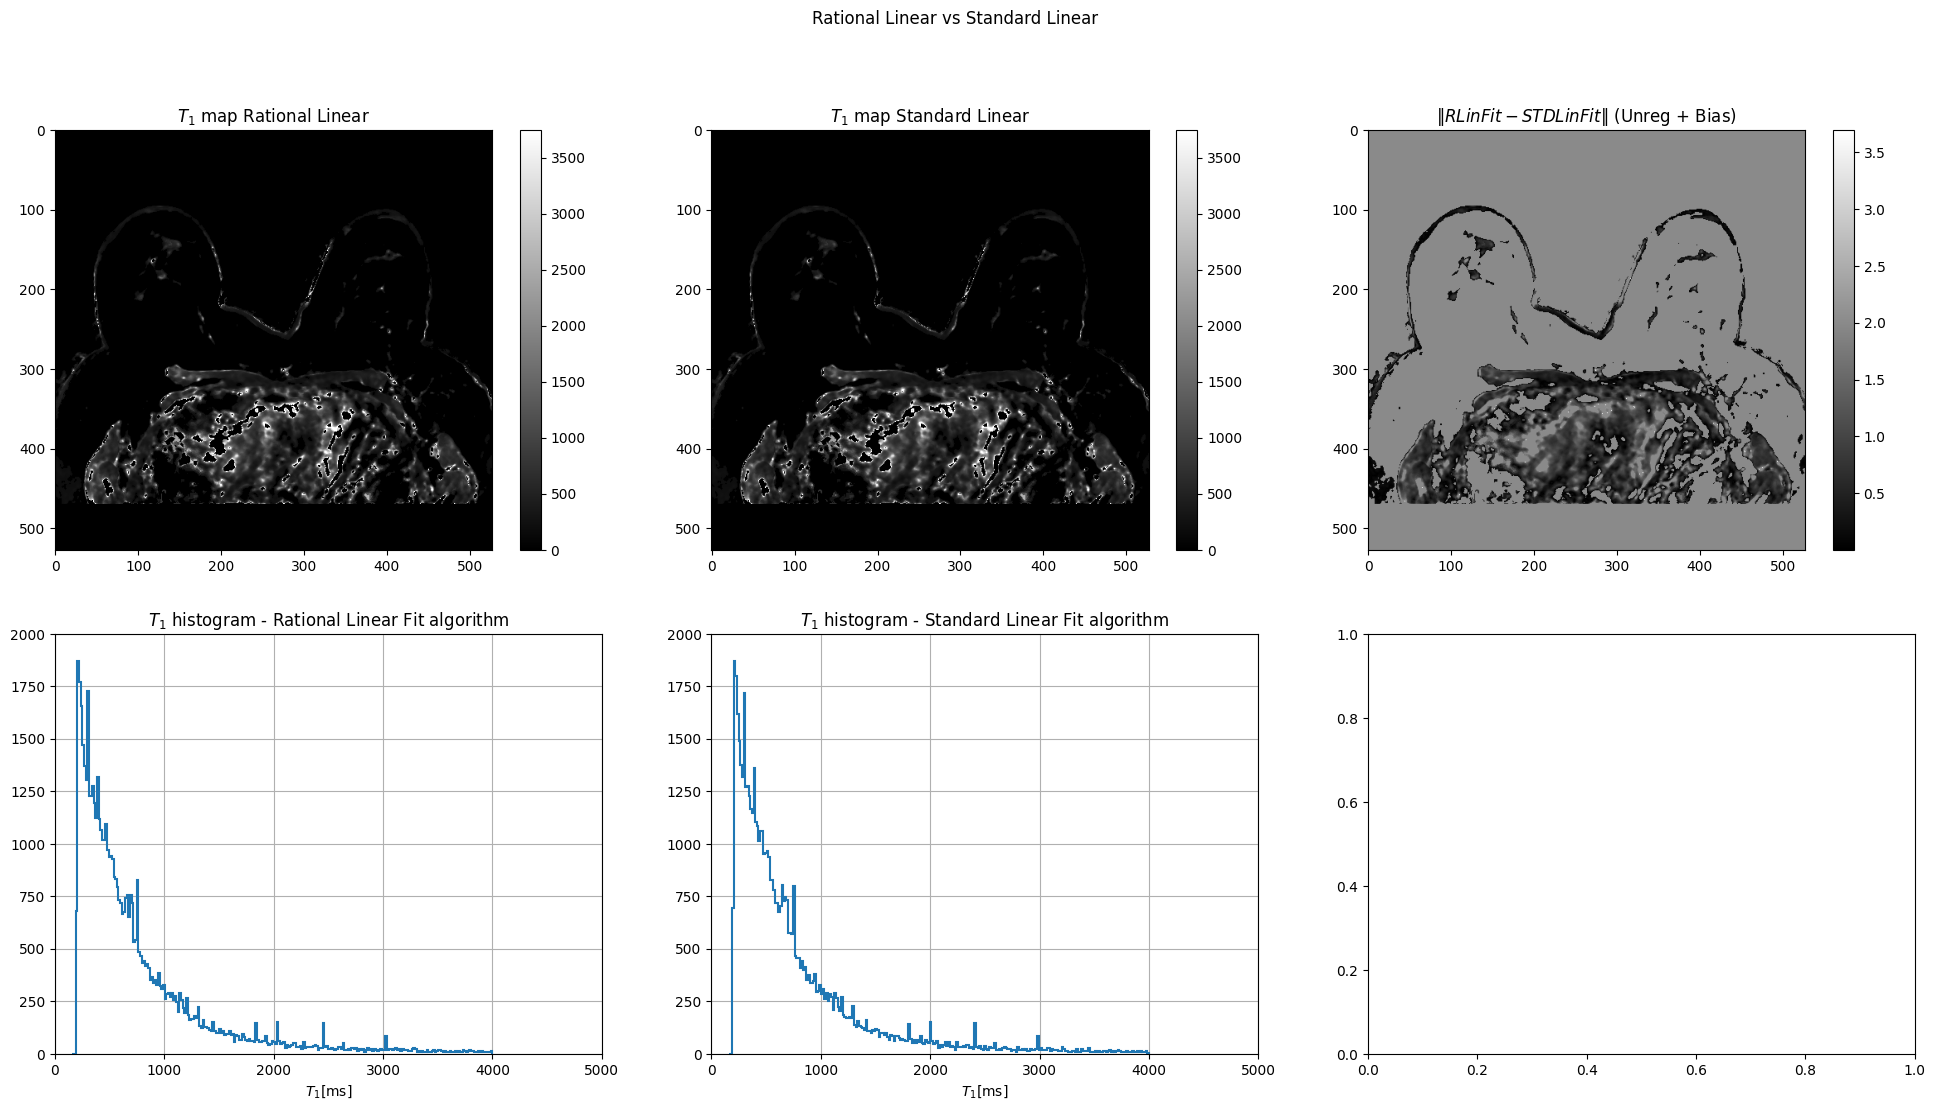

In [42]:
# Rational Linear Fit vs Standard Linear fit
# Unregistered + Bias Correction
T1diff_bias_ureg_rl_stdlfit2fa = np.abs(np.log10(np.abs(T1map_ureg_bias_rlfit - T1map_ureg_bias_stdlfit2fa) + eps_zerodiv))
T1diff_bias_reg_rl_stdlfit2fa = np.abs(np.log10(np.abs(T1map_reg_bias_rlfit - T1map_reg_bias_stdlfit2fa) + eps_zerodiv))

nfigs = 6
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# T1map volumes colourmap
t1map_list = [T1map_ureg_bias_rlfit[tsp[-1], :, :], T1map_ureg_ubias_rlfit[tsp[-1], :, :],
              T1map_ureg_bias_stdlfit2fa[tsp[-1], :, :], T1map_ureg_ubias_stdlfit2fa[tsp[-1], :, :]]
t1map_norm = colors.Normalize(vmin=np.min(t1map_list), vmax=0.75*np.max(t1map_list))

cbar[0] = axr[0].imshow(T1map_ureg_bias_rlfit[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[0].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[0].set_title(r'$T_1$ map Rational Linear')

cbar[1] = axr[1].imshow(T1map_ureg_bias_stdlfit2fa[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[1].set_title(r'$T_1$ map Standard Linear')

cbar[2] = axr[2].imshow(T1diff_bias_ureg_rl_stdlfit2fa[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[2].set_title(r'$\|RLinFit - STDLinFit\|$ (Unreg + Bias)')

# Display the histograms
_, _, bar_container = axr[3].hist(T1map_ureg_bias_rlfit[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[3].set_title(r'$T_1$ histogram - Rational Linear Fit algorithm')
axr[3].set_xlabel(r'$T_1$[ms]')
axr[3].grid(True)
hist_max = bar_container[0].get_xy()[:,1].max()

_, _, bar_container = axr[4].hist(T1map_ureg_bias_stdlfit2fa[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[4].set_title(r'$T_1$ histogram - Standard Linear Fit algorithm')
axr[4].set_xlabel(r'$T_1$[ms]')
axr[4].grid(True)
hist_max = np.ceil(np.max([hist_max, bar_container[0].get_xy()[:,1].max()])/500) * 500

axr[3].axis([0.0, T1ub, 0.0, hist_max])
axr[4].axis([0.0, T1ub, 0.0, hist_max])

fig.suptitle('Rational Linear vs Standard Linear')
for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


### 3 Flip Angles (Pre-Contrast Dyn-eTHRIVE)
As shown above, Bias correction helps with the results, so apply it by default

In [ ]:
hsrdcemri_pattern = 'Dyn'
nt = 6
ns = 120

hsrdcemri_pattern_sequenceID = get_list_element(sequences_in_visit, hsrdcemri_pattern)[0]
hsrdcemri_volume = itk.imread(os.path.join(DCMPATH, patientID, visitID, hsrdcemri_pattern_sequenceID), itk.F)
hsrdcemri_volume_metadata = dict(hsrdcemri_volume)
hsrdcemri_nparray = itk.GetArrayFromImage(hsrdcemri_volume)

# For the flip angle measurement, only need the first volume
# to extract the first spatial volume, is necessary understand the order first:
#  - if the order in the third dimension is: slice0time0, slice1time0, ... --> input_volume[:ns,:,:]
#  - if the order in the third dimension is: slice0time0, slice0time1, ... --> input_volume[::nt,:,:]
moving_10deg_raw_nparray = hsrdcemri_nparray[::nt, :, :]
# moving_10deg_raw_nparray = hsrdcemri_volume_raw[:ns, :, :] 
# Check the slice order:
# fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(2*6.0, 3*5.0))
# slice_pos2plot = range(0, 120, 20)
# axr = ax.ravel()
# for idx, axi in zip(slice_pos2plot, axr):
#     axi.imshow(moving_10deg_raw_nparray[idx,:,:], cmap='gray', aspect='auto')

# The metadata must be updated accordingly to create a valid ITK object:
moving_volume_10deg_raw = itk.GetImageFromArray(moving_10deg_raw_nparray)

# Copy spatial metadata from the first 3D volume (only z-slice 0 to 119)
# Get correct origin, spacing, direction
hsrdce_spacing = list(htrdce_volume_raw.GetSpacing())  # [z, y, x]
hsrdce_origin = list(hsrdcemri_volume.GetOrigin())    # [z, y, x]
hsrdce_direction = hsrdcemri_volume.GetDirection()
# Update spacing for 3D volume (slice spacing = spacing[0] * n_timepoints)
moving_volume_10deg_raw.SetSpacing(hsrdce_spacing)
moving_volume_10deg_raw.SetOrigin(hsrdce_origin)
moving_volume_10deg_raw.SetDirection(hsrdce_direction)

moving_volume_10deg_metadata = dict(moving_volume_10deg_raw)

# Ensure the metadata is consistent with the Fixed Volume:
print(f'Fixed Volume metadata: \n\t{dict(fixed_volume)}')
print(f'Moving (10deg) Volume metadata: \n\t{dict(moving_volume_10deg_raw)}')


In [ ]:
# Check the slice is consistent with the other Flip Angles
nfigs = 3
ncols = 3 #np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# # All flip angles
fa_all_list = [moving_volume_10deg_raw[tsp[-1], :, :], 
               moving_nparray_nt4k[tsp[-1], :, :],
               fixed_nparray_nt4k[tsp[-1], :, :]]
fa_all_norm = colors.Normalize(vmin=np.min(fa_all_list), vmax=np.max(fa_all_list))

cbar[0] = axr[0].imshow(moving_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fa_all_norm)
axr[0].set_title(f'{moving_sequence_pattern}')

cbar[1] = axr[1].imshow(moving_volume_10deg_raw[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fa_all_norm)
axr[1].set_title(f'{hsrdcemri_pattern}')

cbar[2] = axr[2].imshow(fixed_nparray_nt4k[tsp[-1],:,:], cmap='gray', aspect='auto', norm=fa_all_norm)
axr[2].set_title(f'{htrdce_sequence_pattern}')

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


#### Pre-process the additional Flip Angle
Applies NT4K correction and register to the fixed volume

In [ ]:
# Apply the bias correction only to the selected volume
moving_volume_10deg = nt4k_bias_correction(moving_volume_10deg_raw)
moving_10deg_nparray = itk.GetArrayFromImage(moving_volume_10deg)

# Register the new dataset - Focus only on the bias-corrected volume
moving_volume_10deg_reg, result_transform_10deg_parameters = itk.elastix_registration_method(
    fixed_volume, moving_volume_10deg,
    parameter_object=parameter_object,
    log_to_console=False)
moving_10deg_nparray_reg = itk.GetArrayFromImage(moving_volume_10deg_reg)

# Compare before and after pre-processing correction:
moving_10deg_diff = np.abs(np.log10(np.abs(moving_10deg_raw_nparray - moving_10deg_nparray_reg) + eps_zerodiv))

# # Write out the registered volume
# itk.imwrite(moving_volume_10deg_reg, os.path.join(REGPATH, 'moving_FA10_reg.nii.gz'))

spatial_parameters = {'Moving': {'Spacing': moving_volume_10deg.GetSpacing(),
                                 'Origin': moving_volume_10deg.GetOrigin(),
                                 'Directions': moving_volume_10deg.GetDirection()
                                 },
                      'Fixed': {'Spacing': fixed_volume.GetSpacing(),
                                 'Origin': fixed_volume.GetOrigin(),
                                 'Directions': fixed_volume.GetDirection()
                                 }
                    }

for volume_type in spatial_parameters.keys():
    for parameter in spatial_parameters[volume_type].keys():
        print(f'{volume_type} Volume {parameter}: {spatial_parameters[volume_type][parameter]}')


In [ ]:
# Check the processed volume against the original dataset
nfigs = 3
ncols = 3#np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# volumes colourmap
volume_list = [moving_volume_10deg[tsp[-1], :, :], moving_volume_10deg_reg[tsp[-1], :, :]]
volume_list = colors.Normalize(vmin=np.min(volume_list), vmax=np.max(volume_list))

cbar[0] = axr[0].imshow(moving_volume_10deg[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[0].set_title(f'Raw - {hsrdcemri_pattern}')
# axr[0].plot(tsp[0], tsp[1], 'y*')

cbar[1] = axr[1].imshow(moving_volume_10deg_reg[tsp[-1], :, :], cmap='gray', aspect='auto', norm=moving_norm)
axr[1].set_title(f'Pre-Processed - {hsrdcemri_pattern}')
# axr[1].plot(tsp[0], tsp[1], 'y*')

cbar[2] = axr[2].imshow(moving_10deg_diff[tsp[-1], :, :], cmap='gray', aspect='auto')
axr[2].set_title(r'$\|$Raw - Preproc$\|$')
# axr[2].plot(tsp[0], tsp[1], 'y*')


for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


#### Standard Linear Fit with 3 Flip Angles

In [ ]:
# T1 mapping
alfa_i = [5, 10, 15]
flip_angles = {
    'reg_bias_images': [moving_nparray_reg, 
                        moving_10deg_nparray_reg, 
                        fixed_nparray_nt4k],
    'ureg_bias_images': [moving_nparray_nt4k, 
                         moving_10deg_nparray, 
                         fixed_nparray_nt4k],
    'deg': alfa_i,
    'rad': np.deg2rad(alfa_i)}

T1map_reg_bias_stdlfit3fa, M0map_reg_bias_stdlfit3fa = t1fit_vfa(flip_angles['reg_bias_images'], 
                                                                 flip_angles['deg'], 
                                                                 {'TR': float(patient_metadata['RepetitionTime'])}, 
                                                                 FitAlgo = 'std_linear',
                                                                 T1ub=T1ub, T1lb=T1lb)
T1val_reg_bias = np.nanmedian(T1map_reg_bias_stdlfit3fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 3FA'][df_index.index('REGBIAS')] = T1val_reg_bias
itk.imwrite(numpy_to_itk(T1map_reg_bias_stdlfit3fa, fixed_volume), os.path.join(REGPATH, 'T1map_reg_bias_stdlfit3fa.nii.gz'))
itk.imwrite(numpy_to_itk(M0map_reg_bias_stdlfit3fa, fixed_volume), os.path.join(REGPATH, 'M0map_reg_bias_stdlfit3fa.nii.gz'))


T1map_ureg_bias_stdlfit3fa, M0map_ureg_bias_stdlfit3fa = t1fit_vfa(flip_angles['ureg_bias_images'], 
                                                                   flip_angles['deg'], 
                                                                   {'TR': float(patient_metadata['RepetitionTime'])}, 
                                                                   FitAlgo = 'std_linear',
                                                                   T1ub=T1ub, T1lb=T1lb)
T1val_ureg_bias = np.nanmedian(T1map_ureg_bias_stdlfit3fa[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 3FA'][df_index.index('UREGBIAS')] = T1val_ureg_bias
itk.imwrite(numpy_to_itk(T1map_ureg_bias_stdlfit3fa, fixed_volume), os.path.join(REGPATH, 'T1map_ureg_bias_stdlfit3fa.nii.gz'))
itk.imwrite(numpy_to_itk(M0map_ureg_bias_stdlfit3fa, fixed_volume), os.path.join(REGPATH, 'M0map_ureg_bias_stdlfit3fa.nii.gz'))


T1diff_bias_regdiff = np.abs(np.log10(np.abs(T1map_reg_bias_stdlfit3fa - T1map_ureg_bias_stdlfit3fa) + eps_zerodiv))

print('Estimated T1 values for the different tests (average over a small roi centred in the point:')
print('\tREG\t\tUREG')
print(f'BIAS\t{T1val_reg_bias:.2f}[ms]\t\t{T1val_ureg_bias:.2f}[ms]')



In [ ]:
# Compare Standard Linear 2FA vs 3FA
T1diff_bias_regdiff_stdlin2fa3fa = np.abs(np.log10(np.abs(T1map_reg_bias_stdlfit2fa - T1map_reg_bias_stdlfit3fa) + eps_zerodiv))
T1diff_bias_uregdiff_stdlin2fa3fa = np.abs(np.log10(np.abs(T1map_ureg_bias_stdlfit2fa - T1map_ureg_bias_stdlfit3fa) + eps_zerodiv))

# Display the results
# Check level of motion between both FA
nfigs = 6
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# T1map volumes colourmap
t1map_list = [T1map_ureg_bias_stdlfit2fa[tsp[-1], :, :], T1map_reg_bias_stdlfit2fa[tsp[-1], :, :],
              T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :], T1map_reg_bias_stdlfit3fa[tsp[-1], :, :]]
t1map_norm = colors.Normalize(vmin=np.nanmin(t1map_list), vmax=0.75*np.nanmax(t1map_list))

cbar[0] = axr[0].imshow(T1map_ureg_bias_stdlfit2fa[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[0].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[0].set_title(r'$T_1$ map (2FA - Unregistered)')

cbar[1] = axr[1].imshow(T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[1].set_title(r'$T_1$ map (3FA - Unregistered)')

cbar[2] = axr[2].imshow(T1diff_bias_regdiff_stdlin2fa3fa[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[2].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[2].set_title(r'$\|2FA - 3FA\|$')

_, _, bar_container = axr[3].hist(T1map_reg_bias_stdlfit2fa[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[3].set_title(r'$T_1$ histogram - 2FA')
axr[3].set_xlabel(r'$T_1$[ms]')
axr[3].grid(True)
hist_max = bar_container[0].get_xy()[:,1].max()

_, _, bar_container = axr[4].hist(T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :].flatten(), bin_hist, histtype=histtype, linewidth=1.5)
axr[4].set_title(r'$T_1$ histogram - 3FA')
axr[4].set_xlabel(r'$T_1$[ms]')
axr[4].grid(True)
hist_max = np.ceil(np.max([hist_max, bar_container[0].get_xy()[:,1].max()])/500) * 500

axr[3].axis([0.0, T1ub, 0.0, hist_max])
axr[4].axis([0.0, T1ub, 0.0, hist_max])
axr[5].remove()

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


#### Non Linear with 3 Flip Angles

In [ ]:
T1map_reg_bias_nonlin3FA, M0map_reg_bias_nonlin3FA = t1fit_vfa(flip_angles['reg_bias_images'], 
                                                               flip_angles['deg'], 
                                                               {'TR': float(patient_metadata['RepetitionTime'])}, 
                                                               FitAlgo = 'non_linear',
                                                               T1ub=T1ub, T1lb=0.0)

time.sleep(10)
itk.imwrite(numpy_to_itk(T1map_reg_bias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'T1map_reg_bias_nonlin3FA.nii.gz'))
itk.imwrite(numpy_to_itk(M0map_reg_bias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'M0map_reg_bias_nonlin3FA.nii.gz'))

T1map_ureg_bias_nonlin3FA, M0map_ureg_bias_nonlin3FA = t1fit_vfa(flip_angles['ureg_bias_images'],
                                                                 flip_angles['deg'], 
                                                                 {'TR': float(patient_metadata['RepetitionTime'])}, 
                                                                 FitAlgo = 'non_linear',
                                                                 T1ub=T1ub, T1lb=0.0)
time.sleep(10)
itk.imwrite(numpy_to_itk(T1map_ureg_bias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'T1map_ureg_bias_nonlin3FA.nii.gz'))
itk.imwrite(numpy_to_itk(M0map_ureg_bias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'M0map_ureg_bias_nonlin3FA.nii.gz'))

# T1map_reg_ubias_nonlin3FA, M0map_reg_ubias_nonlin3FA = t1fit_vfa(flip_angles['reg_ubias_images'],
#                                                                  flip_angles['deg'], 
#                                                                  {'TR': float(patient_metadata['RepetitionTime'])}, 
#                                                                  FitAlgo = 'non_linear',
#                                                                  T1ub=T1ub, T1lb=0.0)
# time.sleep(10)
# itk.imwrite(numpy_to_itk(T1map_reg_ubias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'T1map_reg_ubias_nonlin3FA.nii.gz'))
# itk.imwrite(numpy_to_itk(M0map_reg_ubias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'M0map_reg_ubias_nonlin3FA.nii.gz'))
# 
# T1map_ureg_ubias_nonlin3FA, M0map_ureg_ubias_nonlin3FA = t1fit_vfa(flip_angles['ureg_ubias_images'], 
#                                                                    flip_angles['deg'], 
#                                                                    {'TR': float(patient_metadata['RepetitionTime'])}, 
#                                                                    FitAlgo = 'non_linear',
#                                                                    T1ub=T1ub, T1lb=0.0)
# time.sleep(10)
# itk.imwrite(numpy_to_itk(T1map_ureg_ubias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'T1map_ureg_ubias_nonlin3FA.nii.gz'))
# itk.imwrite(numpy_to_itk(M0map_ureg_ubias_nonlin3FA, fixed_volume), os.path.join(T1PATH, 'M0map_ureg_ubias_nonlin3FA.nii.gz'))


# T1diff_reg_biasdiff_nonlin3FA = np.abs(np.log10(np.abs(T1map_reg_bias_nonlin3FA - T1map_reg_ubias_nonlin3FA) + eps_zerodiv))
# T1diff_ureg_biasdiff_nonlin3FA = np.abs(np.log10(np.abs(T1map_ureg_bias_nonlin3FA - T1map_ureg_ubias_nonlin3FA) + eps_zerodiv))
T1diff_bias_regdiff_nonlin3FA = np.abs(np.log10(np.abs(T1map_reg_bias_nonlin3FA - T1map_ureg_bias_nonlin3FA) + eps_zerodiv))
# T1diff_ubias_regdiff_nonlin3FA = np.abs(np.log10(np.abs(T1map_ureg_ubias_nonlin3FA - T1map_ureg_ubias_nonlin3FA) + eps_zerodiv))

print('Estimated T1 values for the different tests (average over a small roi centred in the point:')
T1val_reg_bias = np.nanmedian(T1map_reg_bias_nonlin3FA[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 3FA'][df_index.index('REGBIAS')] = T1val_reg_bias
# m0dict1d_results['Standard Linear 3FA'] = m0_1D_rationalLinFit.flatten()

T1val_ureg_bias = np.nanmedian(T1map_ureg_bias_nonlin3FA[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
t1_assessment_results['Standard Linear 3FA'][df_index.index('UREGBIAS')] = T1val_ureg_bias

# T1val_reg_ubias = np.nanmedian(T1map_reg_ubias_nonlin3FA[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
# t1_assessment_results['Standard Linear 3FA'][df_index.index('REGUBIAS')] = T1val_reg_ubias

# T1val_ureg_ubias = np.nanmedian(T1map_ureg_ubias_nonlin3FA[tsp[-1], tsp[1]-5:tsp[1]+5, tsp[0]-5:tsp[0]+5])
# t1_assessment_results['Standard Linear 3FA'][df_index.index('UREGUBIAS')] = T1val_ureg_ubias

print('\tREG\t\tUREG')
print(f'BIAS\t{T1val_reg_bias:.2f}[ms]\t\t{T1val_ureg_bias:.2f}[ms]')
# print(f'UBIAS\t{T1val_reg_ubias:.2f}[ms]\t\t{T1val_ureg_ubias:.2f}[ms]')



In [ ]:
# Compare reg/unreg for nonlinear fit

# Display the results
# Check level of motion between both FA
nfigs = 6
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# T1map volumes colourmap
t1map_list = [T1map_reg_bias_nonlin3FA[tsp[-1], :, :], T1map_ureg_bias_nonlin3FA[tsp[-1], :, :],
            #   T1map_reg_ubias_nonlin3FA[tsp[-1], :, :], T1map_ureg_ubias_nonlin3FA[tsp[-1], :, :],
            ]
t1map_norm = colors.Normalize(vmin=np.nanmin(t1map_list), vmax=0.75*np.nanmax(t1map_list))

cbar[0] = axr[0].imshow(T1map_reg_bias_nonlin3FA[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[0].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[0].set_title(r'$T_1$ map (NonLinFit - Reg)')

cbar[1] = axr[1].imshow(T1map_ureg_bias_nonlin3FA[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[1].set_title(r'$T_1$ map (NonLinFit - Unreg)')

cbar[2] = axr[2].imshow(T1diff_bias_regdiff_nonlin3FA[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[2].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[2].set_title(r'$\|REG - UREG\|$ (+Bias)')


nonlin_bin_hist = np.linspace(T1lb*1.1, T1ub*0.8, num=256)

_, _, bar_container = axr[3].hist(T1map_reg_bias_nonlin3FA[tsp[-1], :, :].flatten(), nonlin_bin_hist, histtype=histtype, linewidth=1.5)
axr[3].set_title(r'$T_1$ histogram - REG')
axr[3].set_xlabel(r'$T_1$[ms]')
axr[3].grid(True)
hist_max = bar_container[0].get_xy()[:,1].max()

_, _, bar_container = axr[4].hist(T1map_ureg_bias_nonlin3FA[tsp[-1], :, :].flatten(), nonlin_bin_hist, histtype=histtype, linewidth=1.5)
axr[4].set_title(r'$T_1$ histogram - UREG')
axr[4].set_xlabel(r'$T_1$[ms]')
axr[4].grid(True)
hist_max = np.ceil(np.max([hist_max, bar_container[0].get_xy()[:,1].max()])/500) * 500

axr[3].axis([0.0, T1ub, 0.0, hist_max])
axr[4].axis([0.0, T1ub, 0.0, hist_max])
axr[5].remove()

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])



In [ ]:
# Compare UREG nonlinFit vs stdLin3FA
T1diff_bias_regdiff_nonlin3FA_stdLin3FA = np.abs(np.log10(np.abs(T1map_reg_bias_nonlin3FA - T1map_ureg_bias_stdlfit3fa) + eps_zerodiv))

# Check level of motion between both FA
nfigs = 6
[fig_width, fig_height] = [6.0, 5.0]
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# T1map volumes colourmap
t1map_list = [T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :], T1map_ureg_bias_nonlin3FA[tsp[-1], :, :]]
t1map_norm = colors.Normalize(vmin=np.nanmin(t1map_list), vmax=0.75*np.nanmax(t1map_list))

cbar[0] = axr[0].imshow(T1map_ureg_bias_nonlin3FA[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[0].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[0].set_title(r'$T_1$ map nonlinear fit (3 FA)')

cbar[1] = axr[1].imshow(T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :], cmap='gray', aspect='auto', norm=t1map_norm)
# axr[1].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[1].set_title(r'$T_1$ map std fit (3 Flip Angles)')

cbar[2] = axr[2].imshow(T1diff_bias_regdiff_nonlin3FA_stdLin3FA[tsp[-1], :, :], cmap='gray', aspect='auto')
# axr[2].plot(tsp[0], tsp[1], 'y*', markersize=8)
axr[2].set_title(r'$\|$nonlin - stdlin$\|$')


_, _, bar_container = axr[3].hist(T1map_reg_bias_nonlin3FA[tsp[-1], :, :].flatten(), nonlin_bin_hist, histtype=histtype, linewidth=1.5)
axr[3].set_title(r'$T_1$ histogram - nonLinFit 3FA')
axr[3].set_xlabel(r'$T_1$[ms]')
axr[3].grid(True)
hist_max = bar_container[0].get_xy()[:,1].max()

_, _, bar_container = axr[4].hist(T1map_ureg_bias_stdlfit3fa[tsp[-1], :, :].flatten(), nonlin_bin_hist, histtype=histtype, linewidth=1.5)
axr[4].set_title(r'$T_1$ histogram - stdLinFit 3FA')
axr[4].set_xlabel(r'$T_1$[ms]')
axr[4].grid(True)
hist_max = np.ceil(np.max([hist_max, bar_container[0].get_xy()[:,1].max()])/500) * 500

axr[3].axis([0.0, T1ub, 0.0, hist_max])
axr[4].axis([0.0, T1ub, 0.0, hist_max])
axr[5].remove()

for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


### T1 map - Conclusion
* The nonlinear fit shows better results, but takes too long (1.5hrs / volume). It is going to be good for later analysis
* The standard linear with 3FA is the second best, therefore, I'll use it when testing other things. 


# Ultrafast DCEMRI

In [22]:
htr_dcemri_pattern = '4D'
visit1_ID = visits_dict[1]

sequences_in_visit = list_folder(os.path.join(DCMPATH, patientID, visit1_ID))
htr_v1_sequenceID = get_list_element(sequences_in_visit, htr_dcemri_pattern)[0]
htrdce_v1_volume_raw = itk.imread(os.path.join(DCMPATH, patientID, visit1_ID, htr_v1_sequenceID), itk.F)
htrdce_v1_volume_metadata = dict(htrdce_v1_volume_raw)

htrdce_v1_volume = itk.image_duplicator(htrdce_v1_volume_raw)
# htrdce_volume = nt4k_bias_correction(htrdce_volume_raw)

htrdce_v1_nparray = itk.GetArrayFromImage(htrdce_v1_volume)
# Reorder the time and slice
htrdce_v1_4darray = np.reshape(htrdce_v1_nparray, [28, 120, 528, 528])
tsp_v1 = [102, 209, 76]


visit2_ID = visits_dict[2]
sequences_in_visit = list_folder(os.path.join(DCMPATH, patientID, visit2_ID))
htr_v2_sequenceID = get_list_element(sequences_in_visit, htr_dcemri_pattern)[0]
htrdce_v2_volume_raw = itk.imread(os.path.join(DCMPATH, patientID, visit2_ID, htr_v2_sequenceID), itk.F)
htrdce_v2_volume_metadata = dict(htrdce_v2_volume_raw)

htrdce_v2_volume = itk.image_duplicator(htrdce_v2_volume_raw)
# htrdce_volume = nt4k_bias_correction(htrdce_volume_raw)

htrdce_v2_nparray = itk.GetArrayFromImage(htrdce_v2_volume)
# Reorder the time and slice
htrdce_v2_4darray = np.reshape(htrdce_v2_nparray, [28, 120, 528, 528])
tsp_v2 = [130, 176, 74]


ImageSeriesReader (0x16c755730): Non uniform sampling or missing slices detected,  maximum nonuniformity:178.447

ImageSeriesReader (0x16d1b04e0): Non uniform sampling or missing slices detected,  maximum nonuniformity:178.447



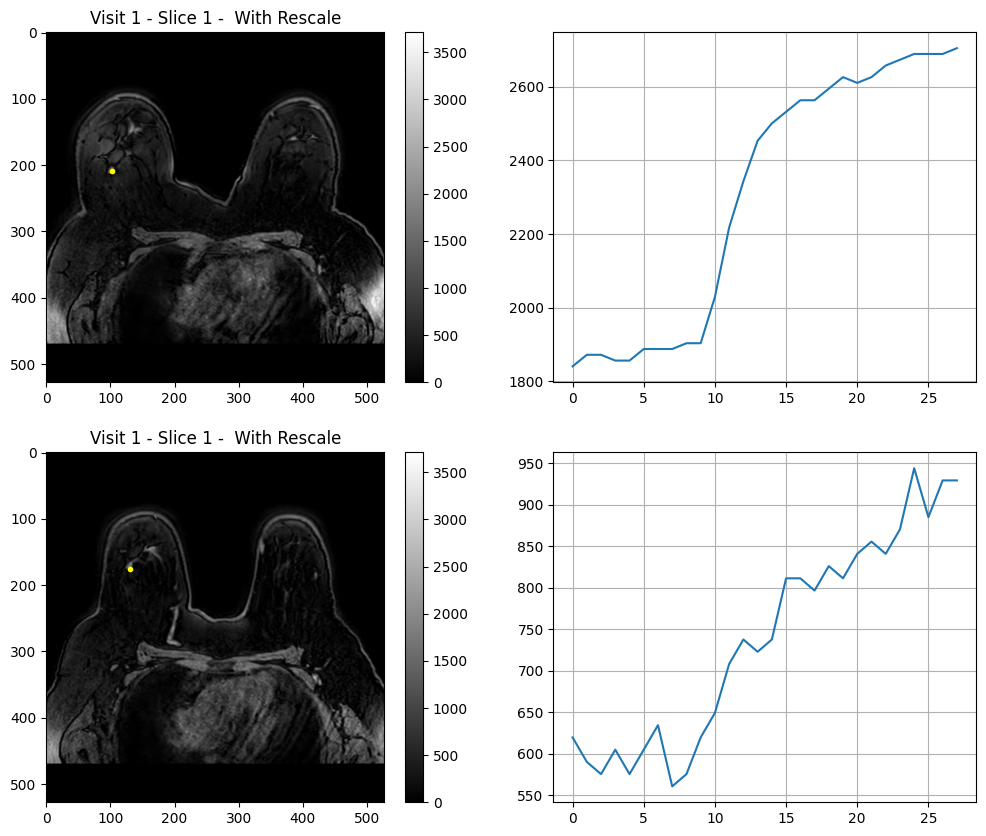

In [23]:
# Display the results
# Check level of motion between both FA
nfigs = 4
[fig_width, fig_height] = [6.0, 5.0]
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# DCEMRI volumes colourmap
htrdce_list = [htrdce_v1_4darray[0, tsp_v1[-1], :, :], htrdce_v2_4darray[0, tsp_v2[-1], :, :]]
htrdce_norm = colors.Normalize(vmin=np.min(htrdce_list), vmax=np.max(htrdce_list))

cbar[0] = axr[0].imshow(htrdce_v1_4darray[0, tsp_v1[-1], :, :], cmap='gray', aspect='auto', norm=htrdce_norm)
axr[0].plot(tsp_v1[0], tsp_v1[1], '.', color='yellow')#, markersize=5')
axr[0].set_title('Visit 1 - Slice 1 -  With Rescale')

axr[1].plot(htrdce_v1_4darray[:, tsp_v1[-1], tsp_v1[1], tsp_v1[0]])
axr[1].grid(True)

cbar[2] = axr[2].imshow(htrdce_v2_4darray[0, tsp_v2[-1], :, :], cmap='gray', aspect='auto', norm=htrdce_norm)
axr[2].plot(tsp_v2[0], tsp_v2[1], '.', color='yellow')#, markersize=5')
axr[2].set_title('Visit 1 - Slice 1 -  With Rescale')

axr[3].plot(htrdce_v2_4darray[:, tsp_v2[-1], tsp_v2[1], tsp_v2[0]])
axr[3].grid(True)


for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])


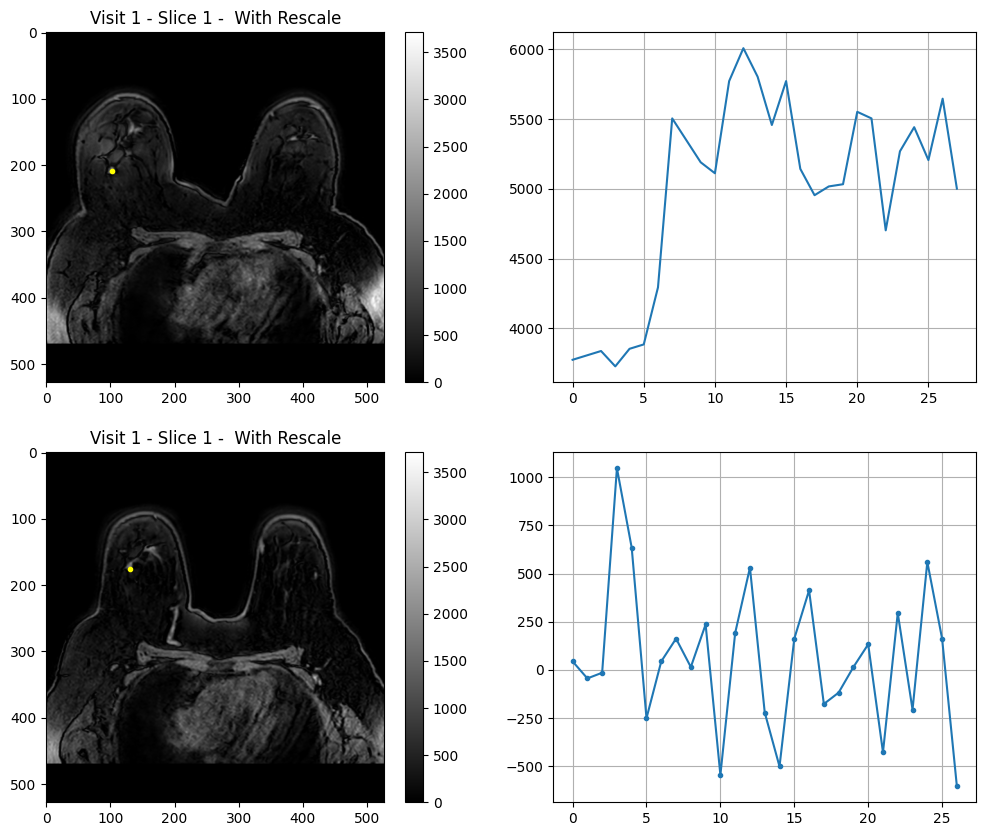

In [ ]:
# Display the results
# Check level of motion between both FA
nfigs = 4
[fig_width, fig_height] = [6.0, 5.0]
ncols = np.ceil(np.sqrt(nfigs))
nrows = np.ceil(nfigs/ncols)

fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(ncols * fig_width, nrows * fig_height))
axr = ax.ravel()
cbar = ['']*nfigs

# DCEMRI volumes colourmap
htrdce_list = [htrdce_v1_4darray[0, tsp_v1[-1], :, :], htrdce_v2_4darray[0, tsp_v2[-1], :, :]]
htrdce_norm = colors.Normalize(vmin=np.min(htrdce_list), vmax=np.max(htrdce_list))

cbar[0] = axr[0].imshow(htrdce_v1_4darray[0, tsp_v1[-1], :, :], cmap='gray', aspect='auto', norm=htrdce_norm)
axr[0].plot(tsp_v1[0], tsp_v1[1], '.', color='yellow')#, markersize=5')
axr[0].set_title('Visit 1 - Slice 1 -  With Rescale')

axr[1].plot(np.max(htrdce_v1_4darray, axis=(1,2,3)))
axr[1].grid(True)

cbar[2] = axr[2].imshow(htrdce_v2_4darray[0, tsp_v2[-1], :, :], cmap='gray', aspect='auto', norm=htrdce_norm)
axr[2].plot(tsp_v2[0], tsp_v2[1], '.', color='yellow')#, markersize=5')
axr[2].set_title('Visit 1 - Slice 1 -  With Rescale')

axr[3].plot(np.diff(np.max(htrdce_v2_4darray, axis=(1,2,3))),'.-')
axr[3].grid(True)


for idx, colour_bar in enumerate(cbar):
    if colour_bar:
        fig.colorbar(colour_bar, ax=axr[idx])
